# Step 8b – Detailed Exploratory Data Analysis

This notebook supplements Step 8 EDA with deeper analyses:

1. **Part A** – Detailed feature distributions (raw vs transformed, normality tests)
2. **Part B** – Adoption lag in-depth analysis (negative lags, lag by region, by originator status)
3. **Part C** – Feature relationships (pairplot, VIF, partial correlations, grouped comparisons)

In [11]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import networkx as nx
from scipy import stats
from pathlib import Path

sns.set_theme(style='whitegrid', context='notebook', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (14, 5),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

DATA = Path('..') / 'data' / 'output'

city_attr   = pd.read_csv(DATA / 'city_attributes.csv')
edges_agg   = pd.read_csv(DATA / 'city_collaboration_edges.csv')
edges_month = pd.read_csv(DATA / 'city_collaboration_edges_monthly.csv')
adoption    = pd.read_csv(DATA / 'city_project_adoption_events.csv')

print(f'city_attributes:              {city_attr.shape}')
print(f'city_collaboration_edges:     {edges_agg.shape}')
print(f'city_collaboration_monthly:   {edges_month.shape}')
print(f'city_project_adoption_events: {adoption.shape}')

city_attributes:              (148, 26)
city_collaboration_edges:     (9636, 4)
city_collaboration_monthly:   (98147, 4)
city_project_adoption_events: (39158, 6)


---
## Part A – Detailed Feature Distributions

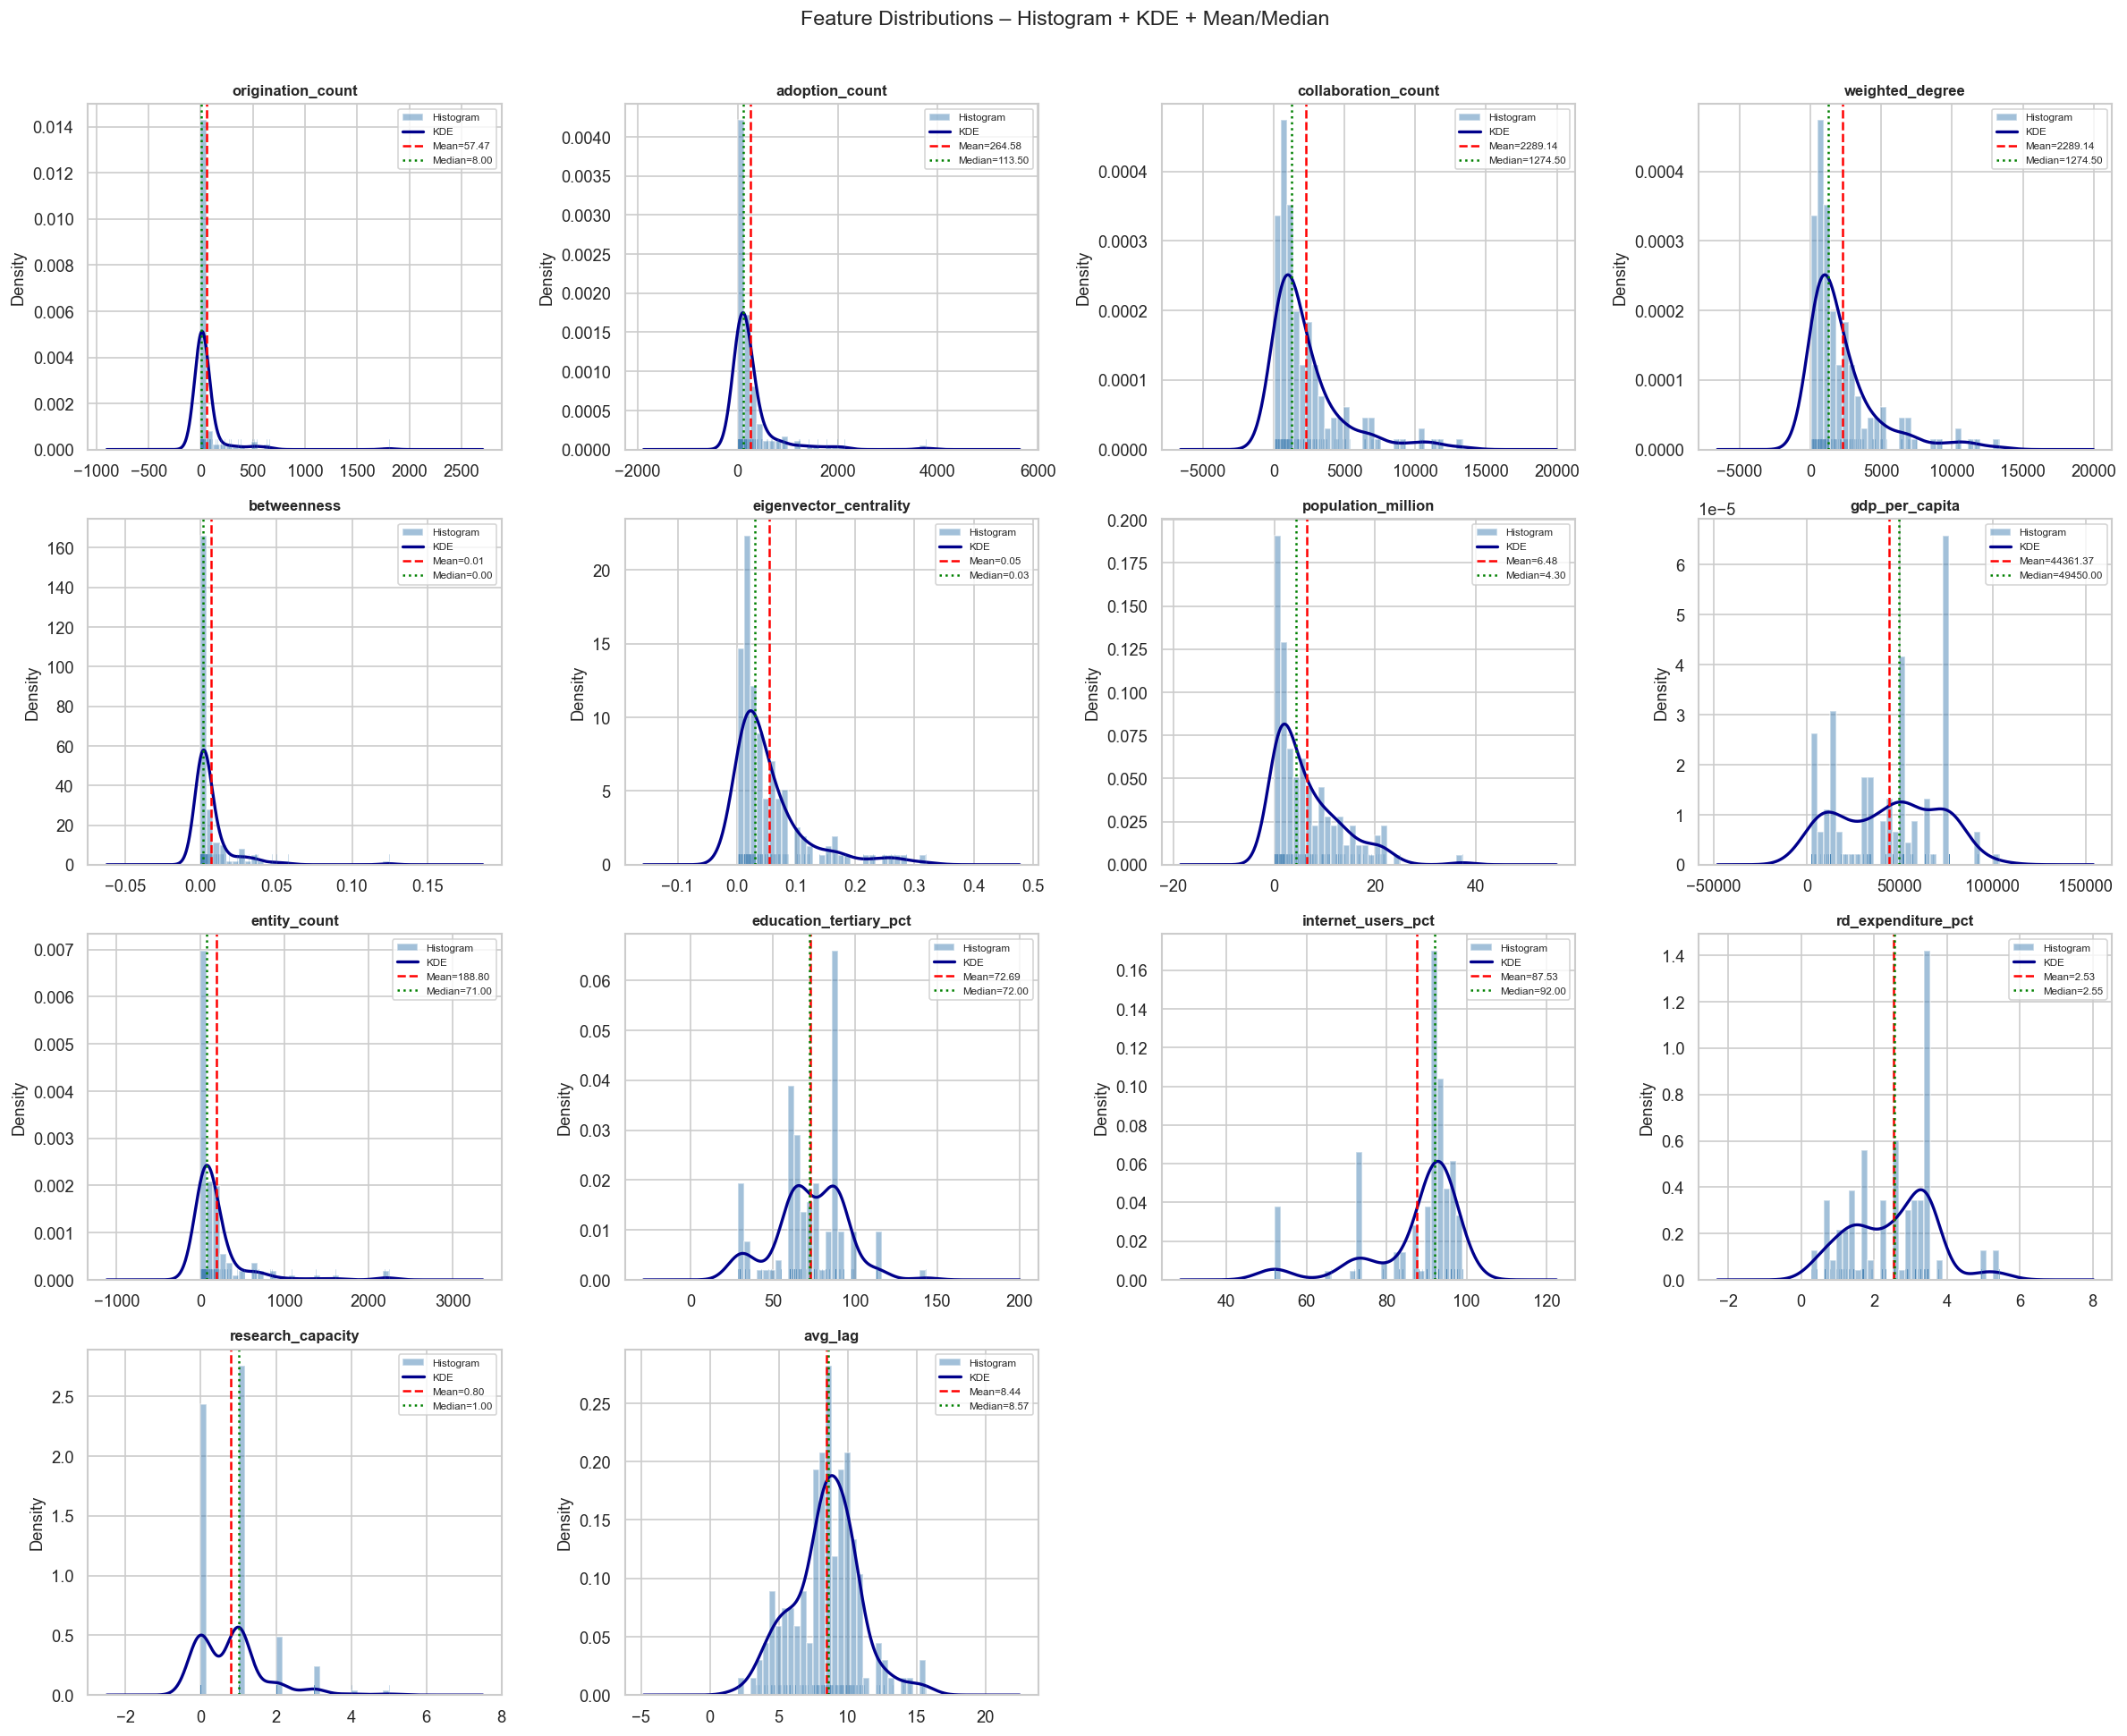

In [12]:
# A1: Comprehensive distribution panel – histogram + KDE + rug for each key feature
key_features = [
    'origination_count', 'adoption_count', 'collaboration_count',
    'weighted_degree', 'betweenness', 'eigenvector_centrality',
    'population_million', 'gdp_per_capita', 'entity_count',
    'education_tertiary_pct', 'internet_users_pct', 'rd_expenditure_pct',
    'research_capacity', 'avg_lag'
]

n_cols = 4
n_rows = (len(key_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(key_features):
    ax = axes[i]
    data = city_attr[col].dropna()
    ax.hist(data, bins=30, density=True, alpha=0.5, color='steelblue', edgecolor='white', label='Histogram')
    if len(data) > 3:
        data.plot.kde(ax=ax, color='darkblue', linewidth=2, label='KDE')
    for val in data:
        ax.axvline(val, ymin=0, ymax=0.03, color='steelblue', alpha=0.3, linewidth=0.5)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean={data.mean():.2f}')
    ax.axvline(data.median(), color='green', linestyle=':', linewidth=1.5, label=f'Median={data.median():.2f}')
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)

for j in range(len(key_features), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature Distributions – Histogram + KDE + Mean/Median', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

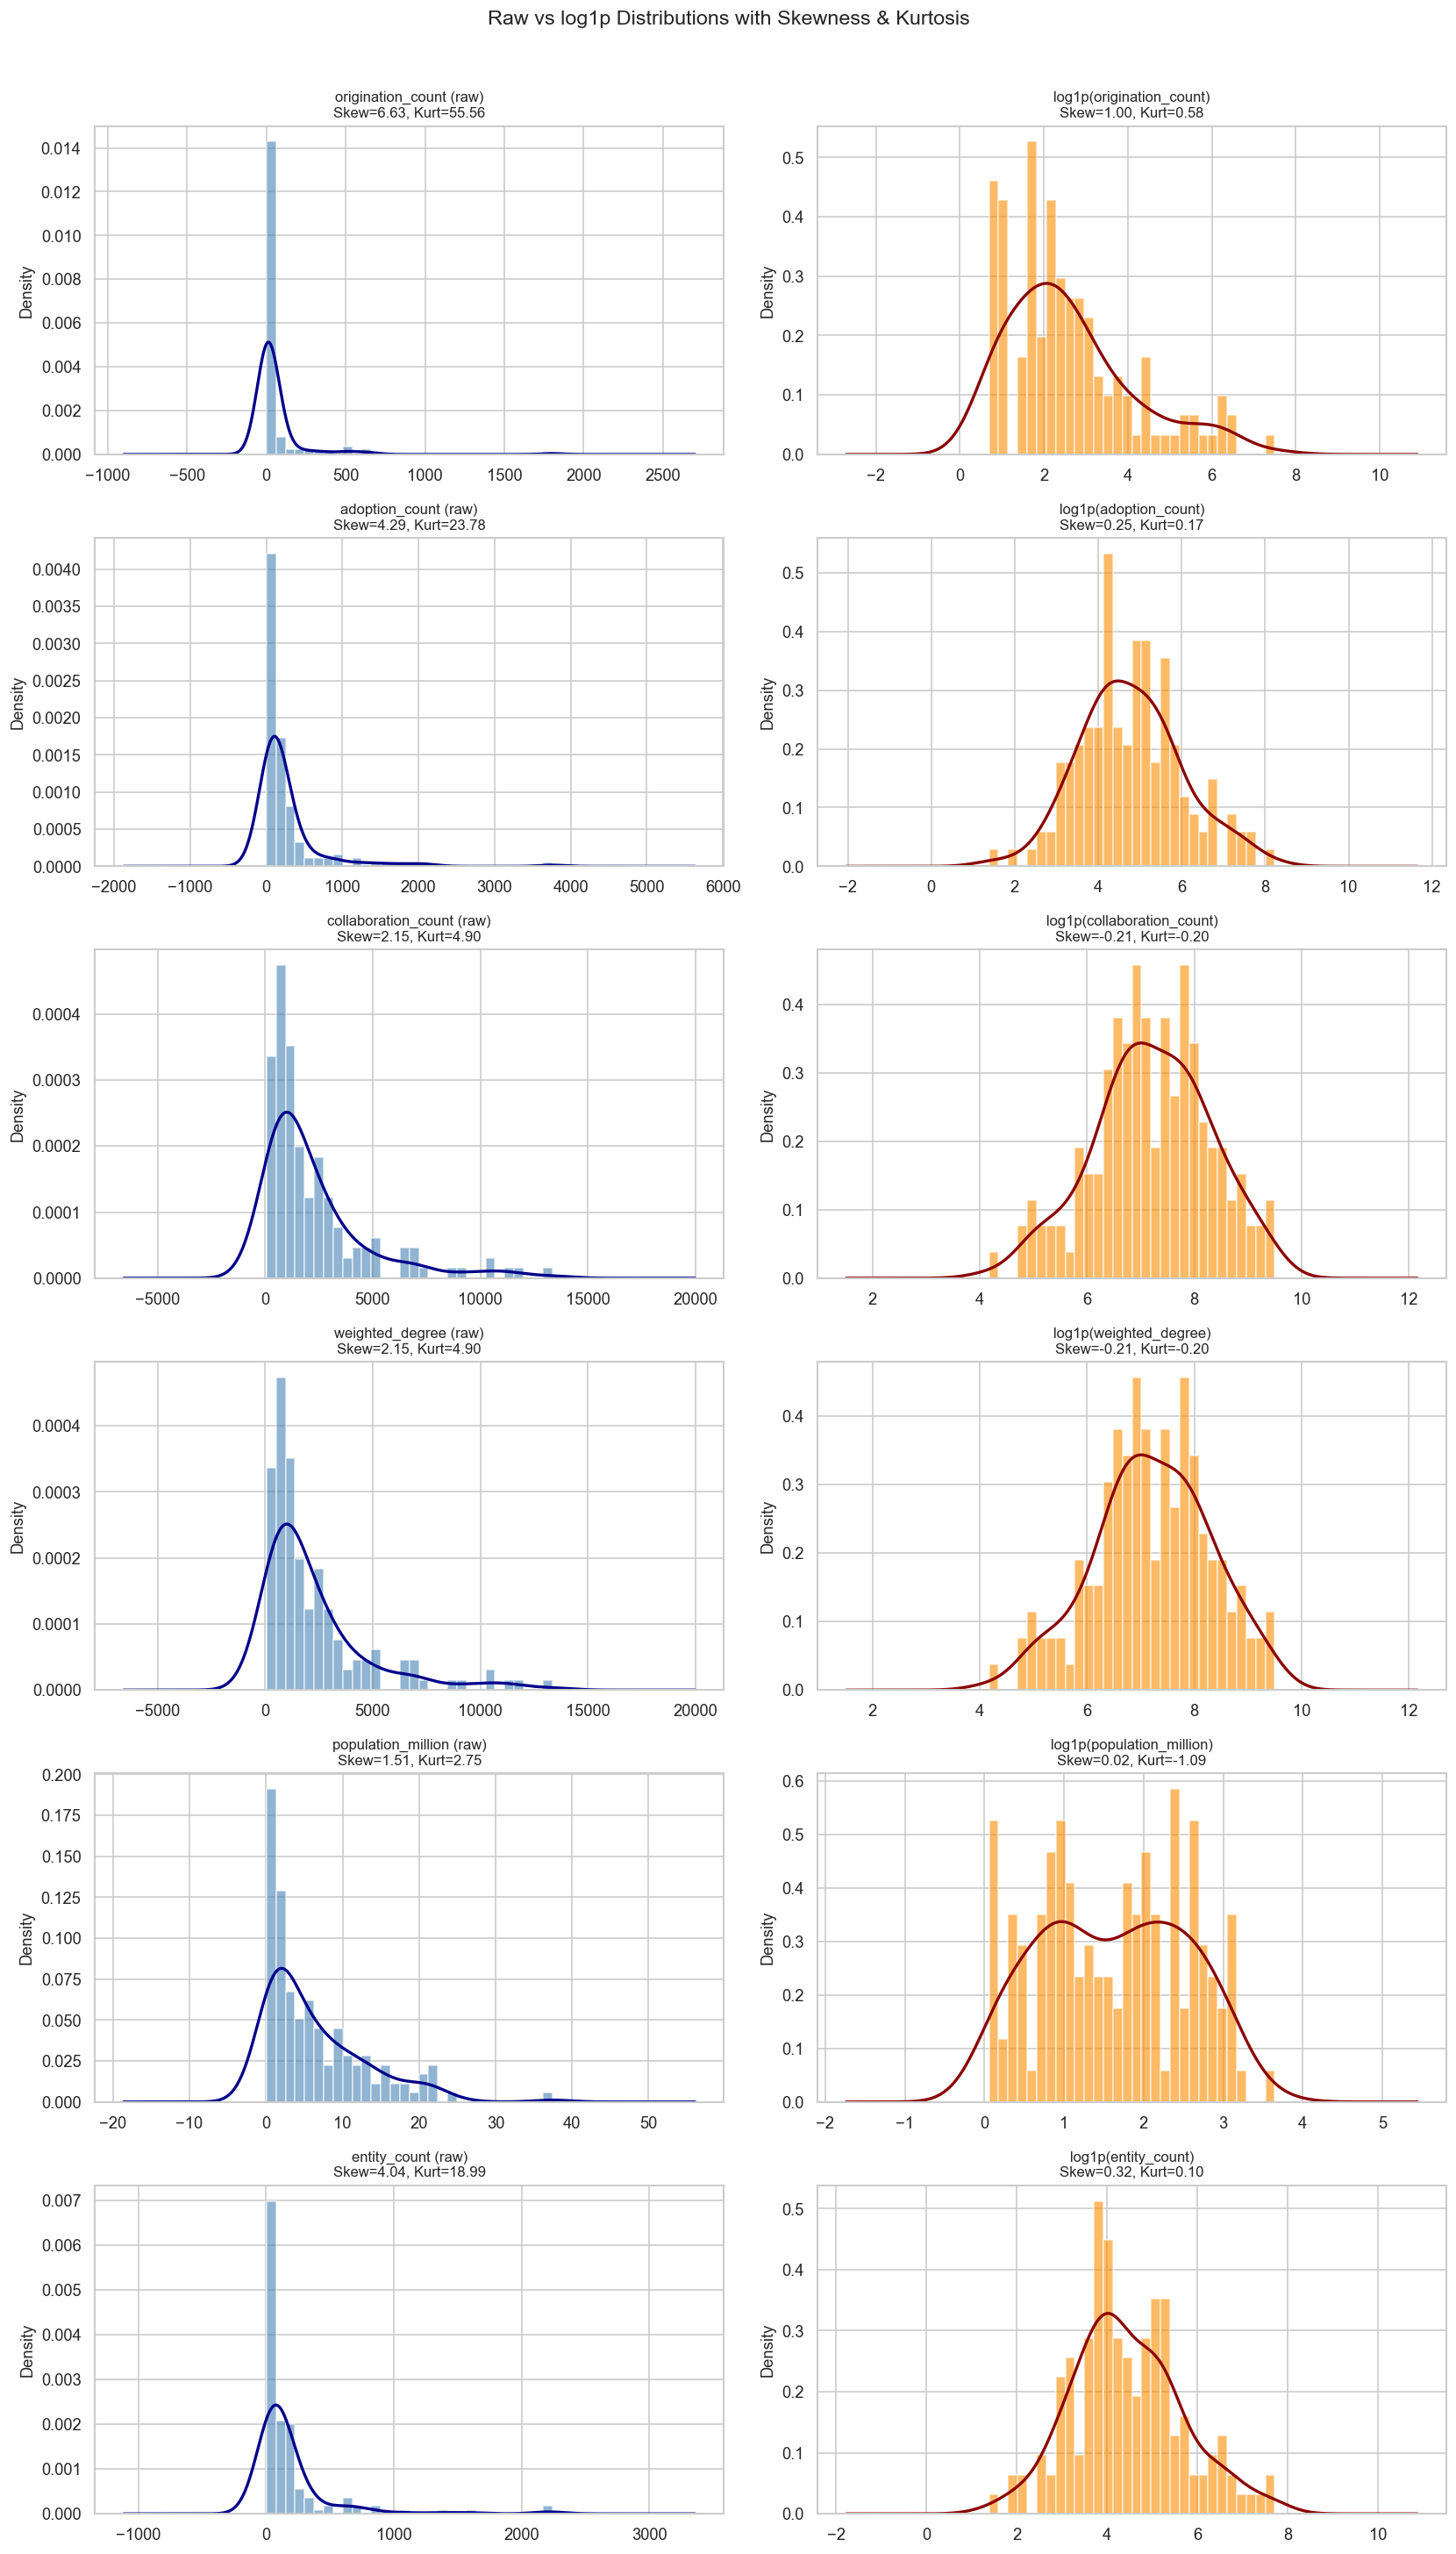

In [13]:
# A2: Raw vs log1p side-by-side comparison for skewed features
skewed_features = ['origination_count', 'adoption_count', 'collaboration_count',
                   'weighted_degree', 'population_million', 'entity_count']

fig, axes = plt.subplots(len(skewed_features), 2, figsize=(14, 4 * len(skewed_features)))

for i, col in enumerate(skewed_features):
    data = city_attr[col].dropna()
    data_pos = data[data > 0]

    ax_raw = axes[i, 0]
    ax_raw.hist(data, bins=30, density=True, alpha=0.6, color='steelblue', edgecolor='white')
    if len(data) > 3:
        data.plot.kde(ax=ax_raw, color='darkblue', linewidth=2)
    skew_raw = data.skew()
    kurt_raw = data.kurtosis()
    ax_raw.set_title(f'{col} (raw)\nSkew={skew_raw:.2f}, Kurt={kurt_raw:.2f}', fontsize=10)

    ax_log = axes[i, 1]
    if len(data_pos) > 0:
        log_data = np.log1p(data_pos)
        ax_log.hist(log_data, bins=30, density=True, alpha=0.6, color='darkorange', edgecolor='white')
        if len(log_data) > 3:
            log_data.plot.kde(ax=ax_log, color='darkred', linewidth=2)
        skew_log = log_data.skew()
        kurt_log = log_data.kurtosis()
        ax_log.set_title(f'log1p({col})\nSkew={skew_log:.2f}, Kurt={kurt_log:.2f}', fontsize=10)
    else:
        ax_log.set_title(f'log1p({col}) – no positive values', fontsize=10)

fig.suptitle('Raw vs log1p Distributions with Skewness & Kurtosis', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [14]:
# A3: Normality tests (Shapiro-Wilk) for raw and log-transformed features
print('=' * 80)
print('NORMALITY TESTS (Shapiro-Wilk)')
print('=' * 80)
print(f'{"Feature":<30} {"Raw W":>10} {"Raw p":>12} {"Log W":>10} {"Log p":>12} {"Transform?":>12}')
print('-' * 80)

test_features = ['origination_count', 'adoption_count', 'collaboration_count',
                 'weighted_degree', 'betweenness', 'eigenvector_centrality',
                 'population_million', 'gdp_per_capita', 'entity_count',
                 'avg_lag']

for col in test_features:
    data = city_attr[col].dropna()
    if len(data) < 3:
        continue
    w_raw, p_raw = stats.shapiro(data)

    data_pos = data[data > 0]
    if len(data_pos) >= 3:
        log_data = np.log1p(data_pos)
        w_log, p_log = stats.shapiro(log_data)
    else:
        w_log, p_log = float('nan'), float('nan')

    better = 'Yes' if (not np.isnan(p_log) and p_log > p_raw) else 'No'
    print(f'{col:<30} {w_raw:>10.4f} {p_raw:>12.6f} {w_log:>10.4f} {p_log:>12.6f} {better:>12}')

print('\n(Transform? = Yes if log1p p-value > raw p-value, suggesting closer to normal)')

NORMALITY TESTS (Shapiro-Wilk)
Feature                             Raw W        Raw p      Log W        Log p   Transform?
--------------------------------------------------------------------------------
origination_count                  0.3167     0.000000     0.9158     0.000000          Yes
adoption_count                     0.5125     0.000000     0.9919     0.560920          Yes
collaboration_count                0.7475     0.000000     0.9912     0.492704          Yes
weighted_degree                    0.7475     0.000000     0.9912     0.492704          Yes
betweenness                        0.4915     0.000000     0.5165     0.000000          Yes
eigenvector_centrality             0.7399     0.000000     0.7642     0.000000          Yes
population_million                 0.8397     0.000000     0.9645     0.000926          Yes
gdp_per_capita                     0.9285     0.000002     0.8284     0.000000           No
entity_count                       0.5058     0.000000     0

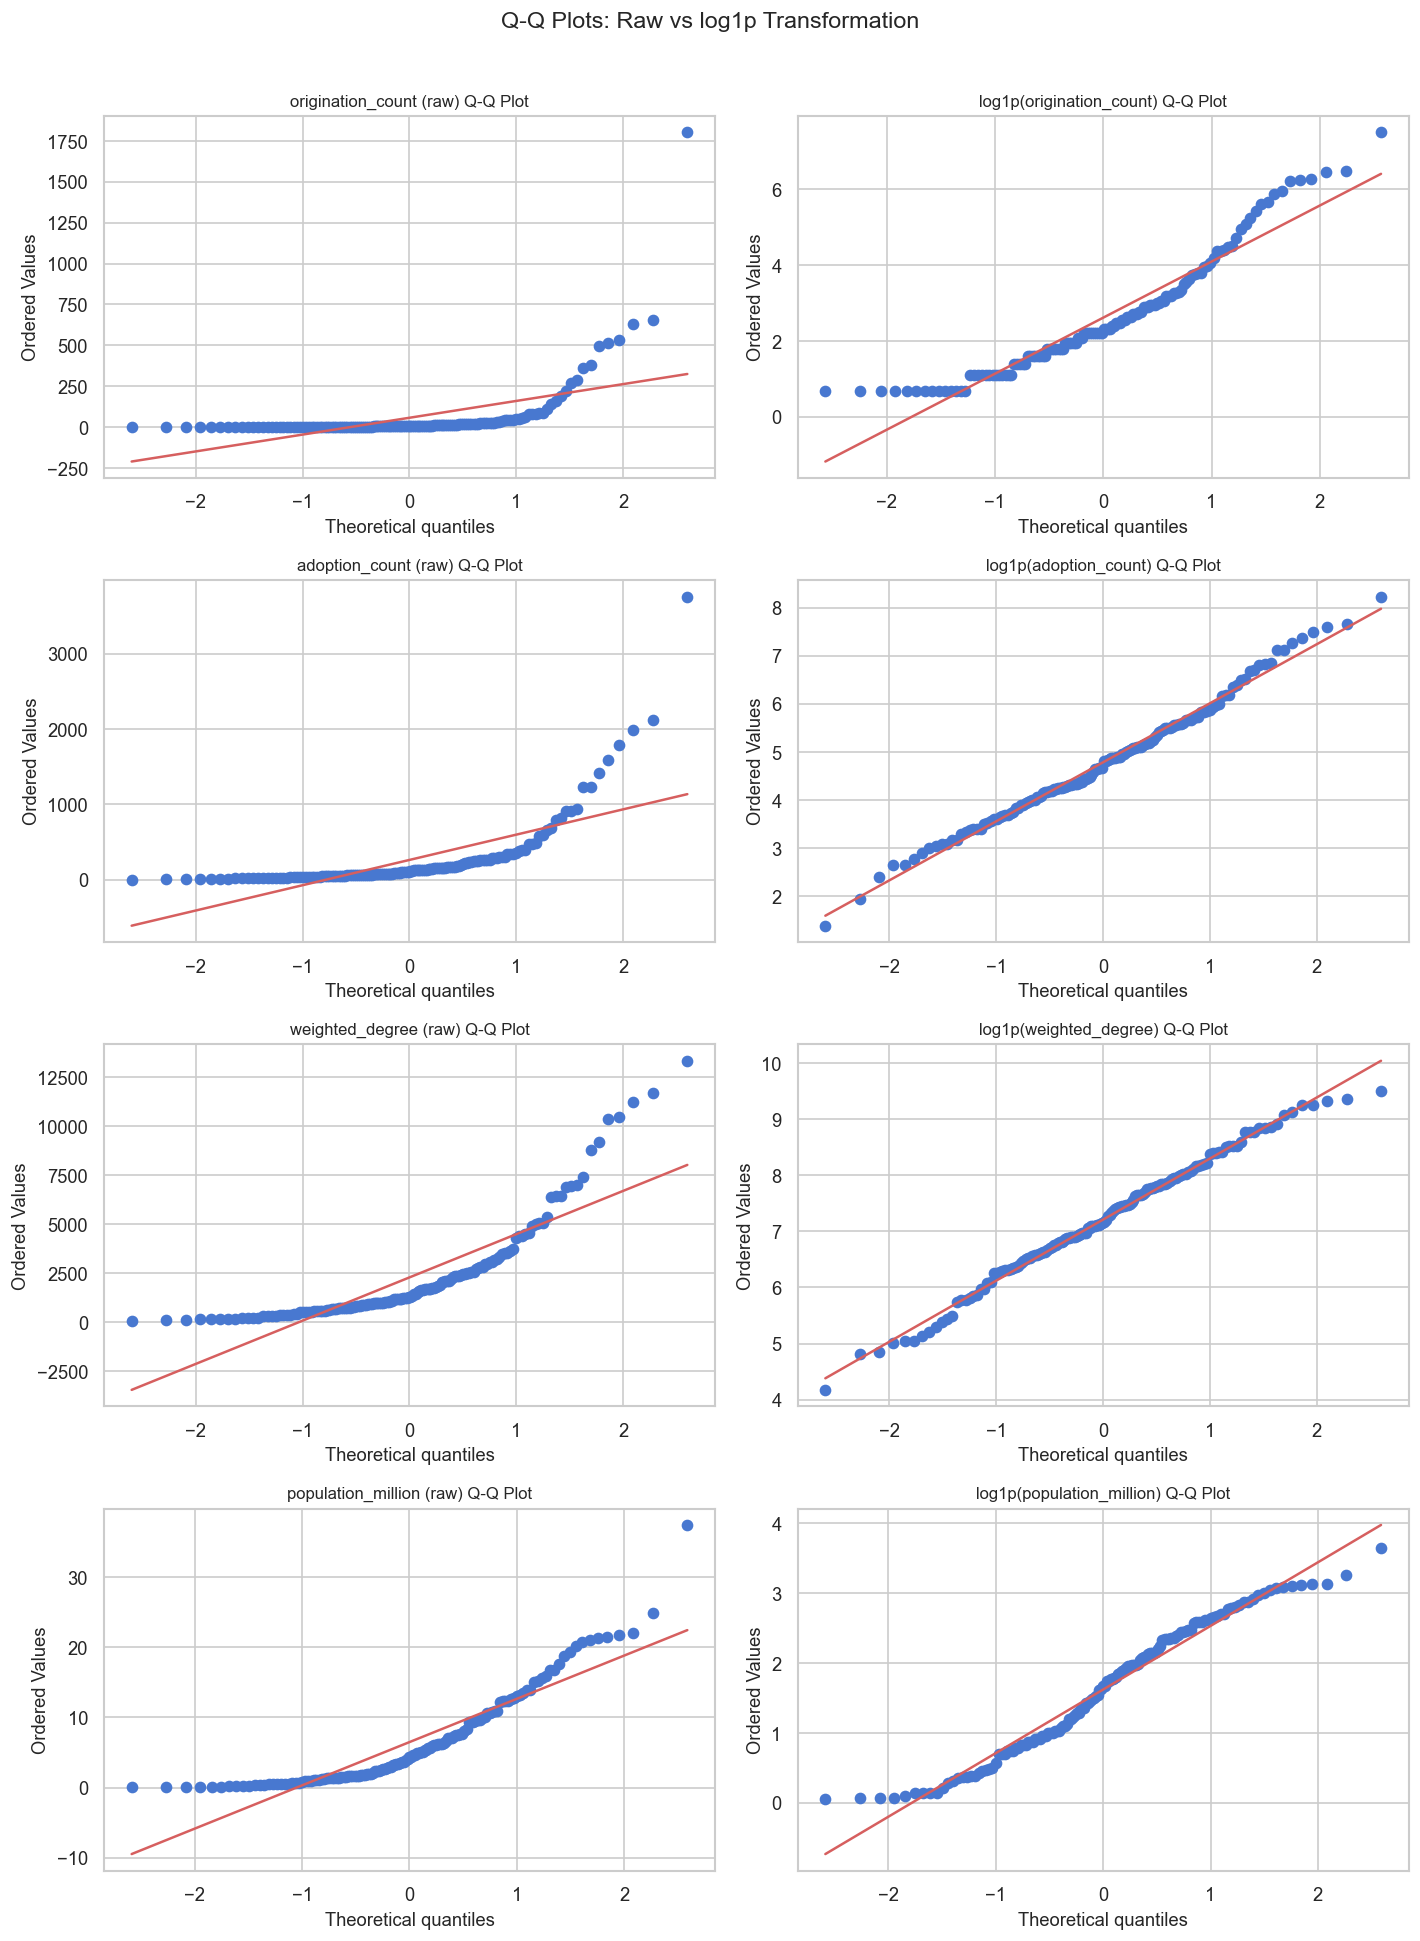

In [15]:
# A4: Q-Q plots for selected features (raw vs log-transformed)
qq_features = ['origination_count', 'adoption_count', 'weighted_degree', 'population_million']

fig, axes = plt.subplots(len(qq_features), 2, figsize=(12, 4 * len(qq_features)))

for i, col in enumerate(qq_features):
    data = city_attr[col].dropna()
    data_pos = data[data > 0]

    stats.probplot(data, dist='norm', plot=axes[i, 0])
    axes[i, 0].set_title(f'{col} (raw) Q-Q Plot', fontsize=10)

    if len(data_pos) >= 3:
        stats.probplot(np.log1p(data_pos), dist='norm', plot=axes[i, 1])
        axes[i, 1].set_title(f'log1p({col}) Q-Q Plot', fontsize=10)
    else:
        axes[i, 1].set_visible(False)

fig.suptitle('Q-Q Plots: Raw vs log1p Transformation', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [16]:
# A5: Descriptive statistics summary including skewness, kurtosis
desc_cols = ['entity_count', 'origination_count', 'adoption_count',
             'avg_lag', 'median_lag', 'collaboration_count', 'weighted_degree',
             'betweenness', 'eigenvector_centrality',
             'population_million', 'gdp_per_capita',
             'education_tertiary_pct', 'internet_users_pct', 'rd_expenditure_pct',
             'research_capacity']

summary = city_attr[desc_cols].describe().T
summary['skewness'] = city_attr[desc_cols].skew()
summary['kurtosis'] = city_attr[desc_cols].kurtosis()
summary['IQR'] = summary['75%'] - summary['25%']
summary['CV'] = summary['std'] / summary['mean']
display(summary.round(3))

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,IQR,CV
entity_count,148.0,188.804,338.967,3.000,39.750,71.000,183.000,2239.000,4.041,18.989,143.250,1.795
origination_count,148.0,57.466,184.833,0.000,2.000,8.000,23.000,1802.000,6.633,55.559,21.000,3.216
adoption_count,148.0,264.581,468.588,3.000,53.750,113.500,257.250,3757.000,4.290,23.778,203.500,1.771
avg_lag,148.0,8.438,2.398,2.020,7.098,8.575,9.912,15.670,0.060,0.606,2.815,0.284
median_lag,148.0,5.118,2.716,0.000,4.000,5.000,6.000,15.000,0.569,1.638,2.000,0.531
collaboration_count,148.0,2289.135,2527.837,64.000,699.750,1274.500,2828.250,13337.000,2.150,4.900,2128.500,1.104
weighted_degree,148.0,2289.135,2527.837,64.000,699.750,1274.500,2828.250,13337.000,2.150,4.900,2128.500,1.104
betweenness,148.0,0.007,0.014,0.000,0.000,0.002,0.006,0.124,4.770,31.621,0.006,2.080
eigenvector_centrality,148.0,0.055,0.062,0.001,0.016,0.030,0.068,0.319,2.159,4.825,0.051,1.127
population_million,143.0,6.481,6.654,0.060,1.400,4.300,9.750,37.400,1.511,2.748,8.350,1.027


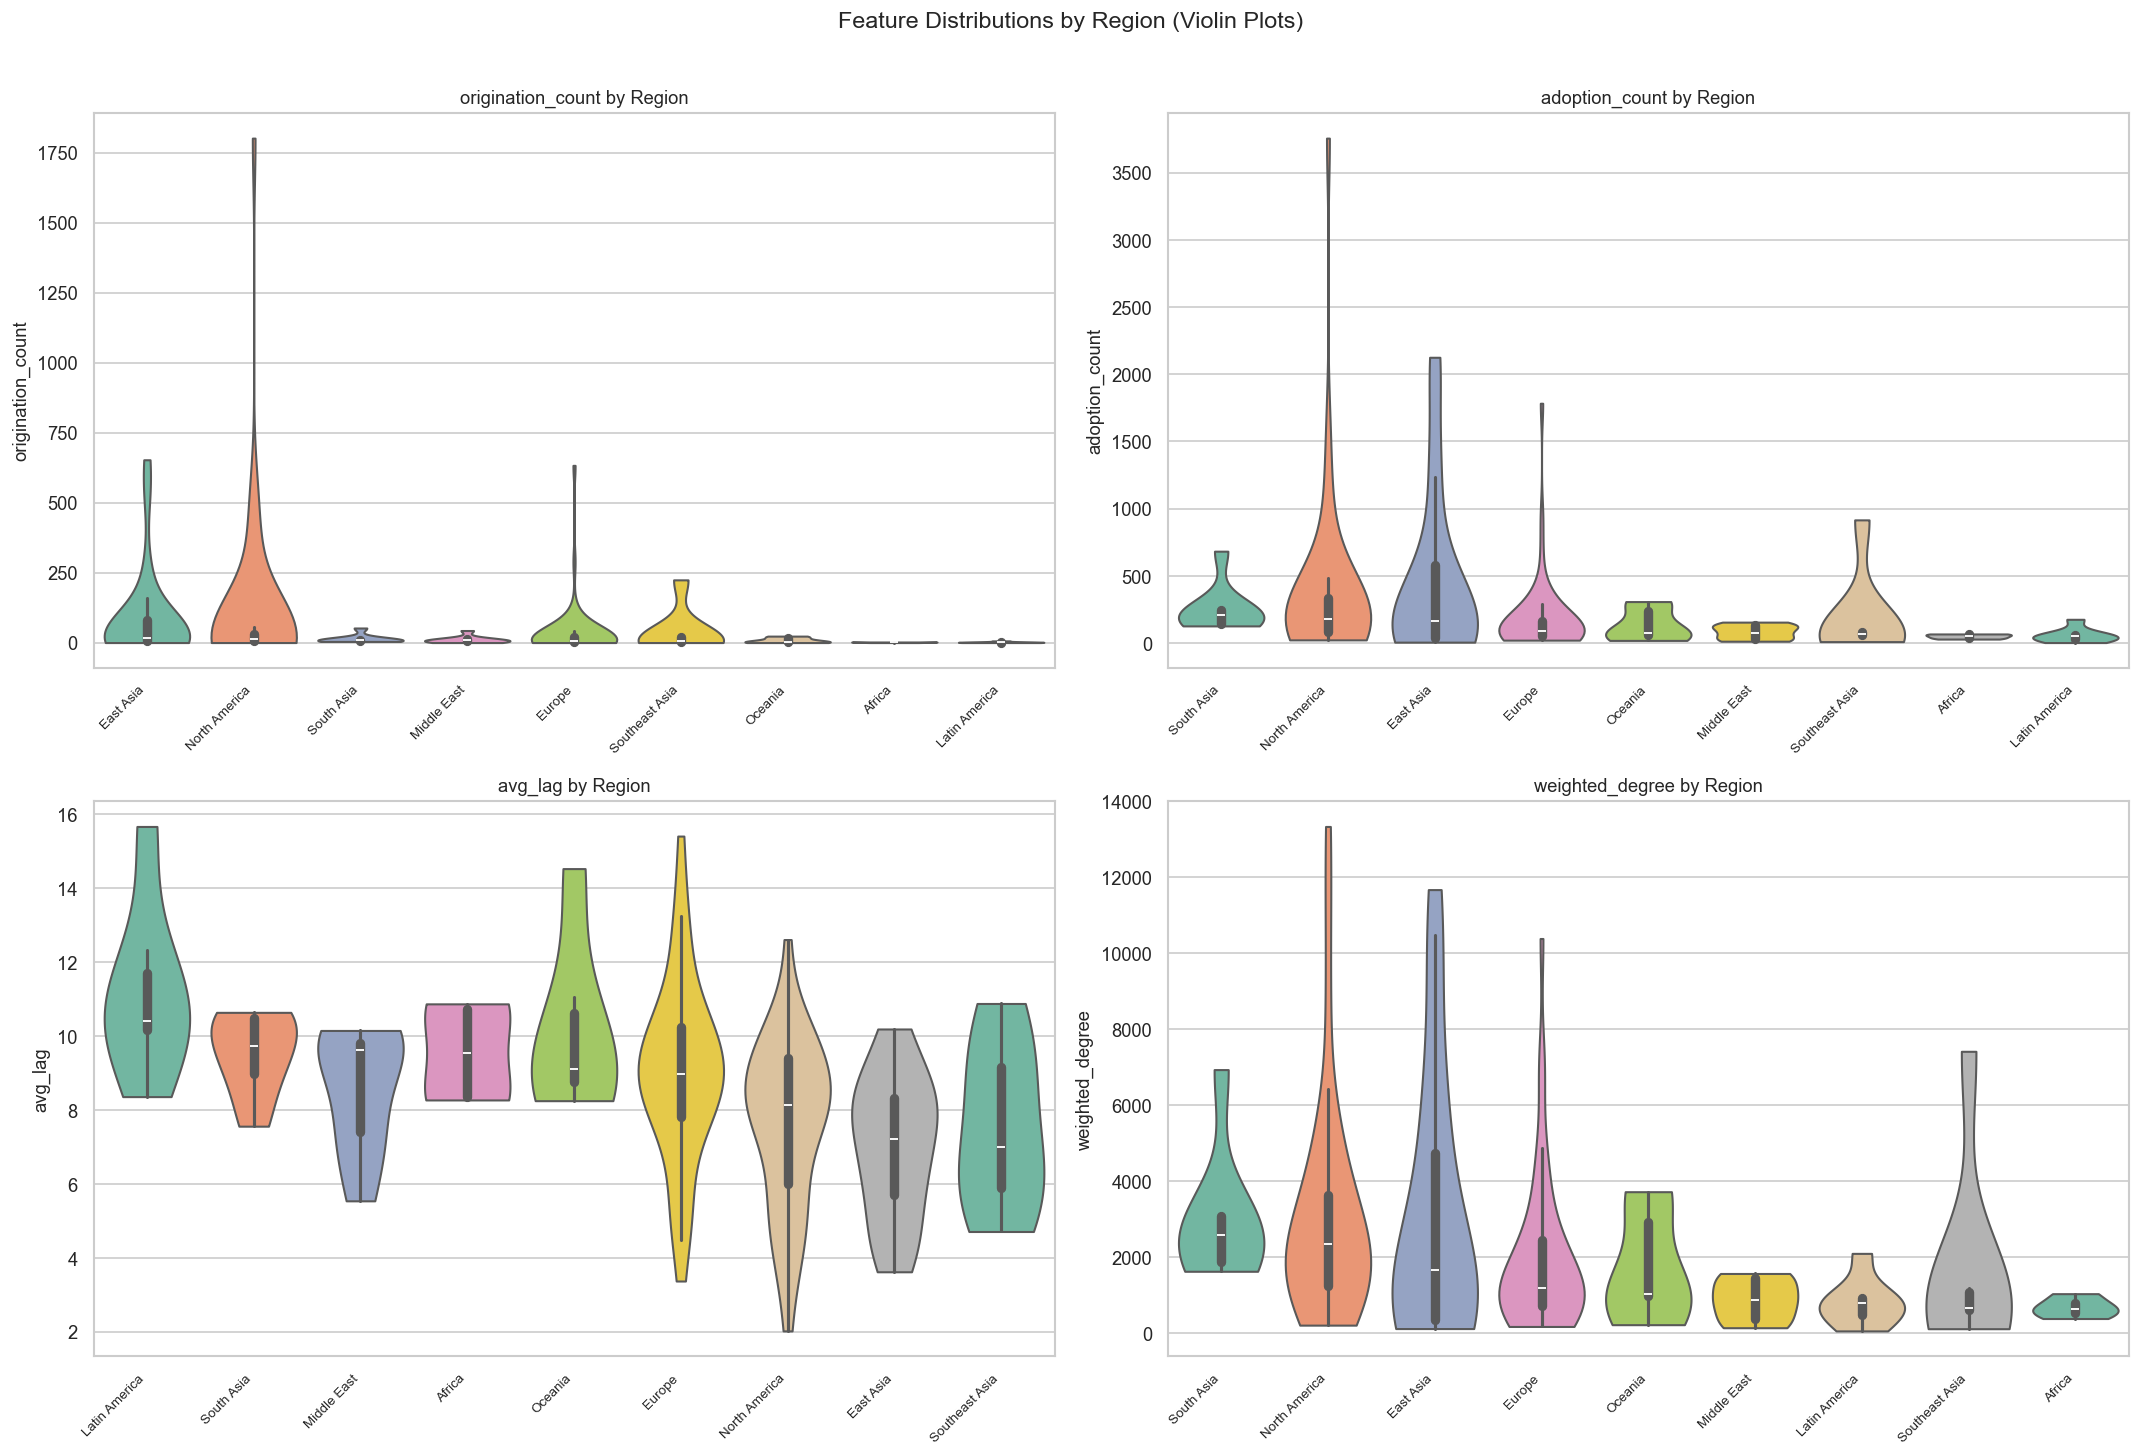

In [17]:
# A6: Violin plots of key features by region
violin_features = ['origination_count', 'adoption_count', 'avg_lag', 'weighted_degree']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for ax, col in zip(axes.flatten(), violin_features):
    data = city_attr.dropna(subset=[col])
    order = data.groupby('region')[col].median().sort_values(ascending=False).index
    sns.violinplot(data=data, x='region', y=col, ax=ax, order=order,
                   inner='box', palette='Set2', cut=0)
    ax.set_title(f'{col} by Region', fontsize=11)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.set_xlabel('')

fig.suptitle('Feature Distributions by Region (Violin Plots)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## Part B – Adoption Lag In-Depth Analysis

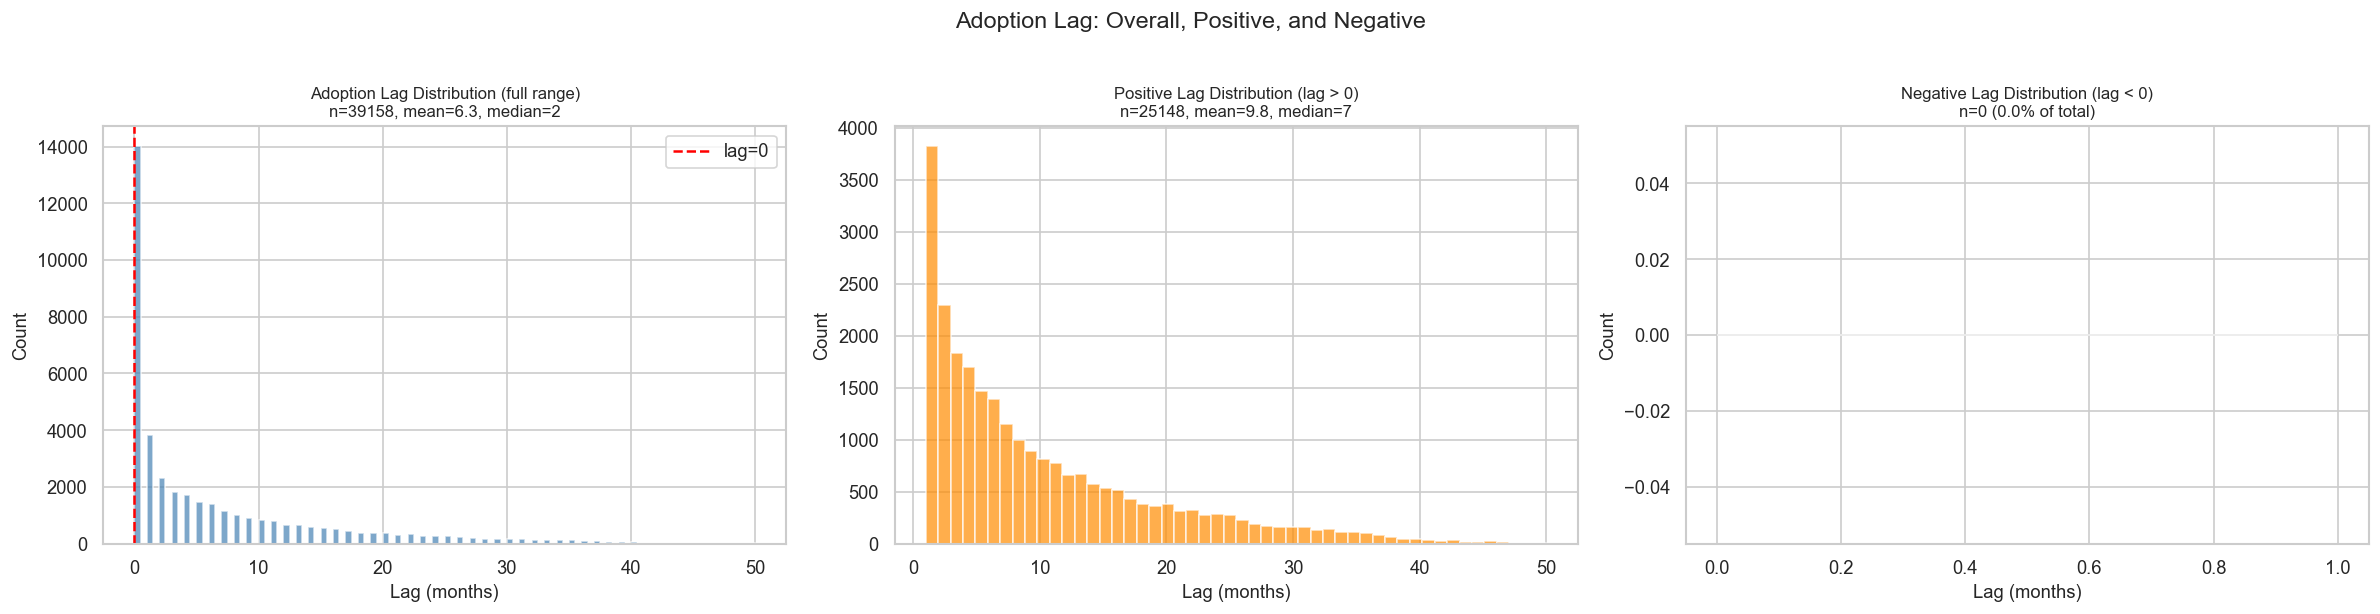

In [18]:
# B1: Overall lag distribution (histogram)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Full range
axes[0].hist(adoption['lag'], bins=100, edgecolor='white', alpha=0.7, color='steelblue')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='lag=0')
axes[0].set_title(f'Adoption Lag Distribution (full range)\nn={len(adoption)}, '
                  f'mean={adoption["lag"].mean():.1f}, median={adoption["lag"].median():.0f}', fontsize=10)
axes[0].set_xlabel('Lag (months)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Positive lags only (non-originator adoptions with lag > 0)
pos_lag = adoption[adoption['lag'] > 0]['lag']
axes[1].hist(pos_lag, bins=50, edgecolor='white', alpha=0.7, color='darkorange')
axes[1].set_title(f'Positive Lag Distribution (lag > 0)\nn={len(pos_lag)}, '
                  f'mean={pos_lag.mean():.1f}, median={pos_lag.median():.0f}', fontsize=10)
axes[1].set_xlabel('Lag (months)')
axes[1].set_ylabel('Count')

# Negative lags
neg_lag = adoption[adoption['lag'] < 0]['lag']
axes[2].hist(neg_lag, bins=30, edgecolor='white', alpha=0.7, color='indianred')
axes[2].set_title(f'Negative Lag Distribution (lag < 0)\nn={len(neg_lag)} '
                  f'({len(neg_lag)/len(adoption)*100:.1f}% of total)', fontsize=10)
axes[2].set_xlabel('Lag (months)')
axes[2].set_ylabel('Count')

fig.suptitle('Adoption Lag: Overall, Positive, and Negative', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# B2: Lag summary statistics
print('=' * 70)
print('ADOPTION LAG SUMMARY')
print('=' * 70)

print(f'Total adoption events:         {len(adoption)}')
print(f'  Originator (lag=0, is_orig=1): {((adoption["is_originator"]==1)).sum()}')
print(f'  Lag = 0 (total):               {(adoption["lag"]==0).sum()}')
print(f'  Lag > 0:                       {(adoption["lag"]>0).sum()}')
print(f'  Lag < 0:                       {(adoption["lag"]<0).sum()}')
print()

for label, subset in [('All lags', adoption['lag']),
                       ('Positive lags (>0)', adoption[adoption['lag']>0]['lag']),
                       ('Negative lags (<0)', adoption[adoption['lag']<0]['lag']),
                       ('Non-originator lags', adoption[adoption['is_originator']==0]['lag'])]:
    if len(subset) == 0:
        continue
    print(f'  {label}:')
    print(f'    Mean   = {subset.mean():.2f}')
    print(f'    Median = {subset.median():.0f}')
    print(f'    Std    = {subset.std():.2f}')
    print(f'    Min    = {subset.min()}')
    print(f'    Max    = {subset.max()}')
    pcts = subset.quantile([0.10, 0.25, 0.50, 0.75, 0.90]).to_dict()
    pct_str = ', '.join(f'P{int(k*100)}={v:.0f}' for k, v in pcts.items())
    print(f'    Percentiles: {pct_str}')
    print()

ADOPTION LAG SUMMARY
Total adoption events:         39158
  Originator (lag=0, is_orig=1): 8505
  Lag = 0 (total):               14010
  Lag > 0:                       25148
  Lag < 0:                       0

  All lags:
    Mean   = 6.28
    Median = 2
    Std    = 8.78
    Min    = 0
    Max    = 50
    Percentiles: P10=0, P25=0, P50=2, P75=9, P90=19

  Positive lags (>0):
    Mean   = 9.78
    Median = 7
    Std    = 9.26
    Min    = 1
    Max    = 50
    Percentiles: P10=1, P25=3, P50=7, P75=14, P90=24

  Non-originator lags:
    Mean   = 8.03
    Median = 5
    Std    = 9.19
    Min    = 0
    Max    = 50
    Percentiles: P10=0, P25=1, P50=5, P75=12, P90=22



In [20]:
# B3: Negative lag deep dive – which cities and projects
neg_events = adoption[adoption['lag'] < 0].copy()
print(f'Negative lag events: {len(neg_events)}')
print(f'Unique cities involved: {neg_events["city"].nunique()}')
print(f'Unique projects involved: {neg_events["project_id"].nunique()}')
print()

# Cities with most negative-lag events
print('Top 15 cities with negative-lag events:')
neg_city = neg_events.groupby('city').agg(
    neg_count=('lag', 'count'),
    mean_neg_lag=('lag', 'mean'),
    min_lag=('lag', 'min')
).sort_values('neg_count', ascending=False).head(15)
display(neg_city.round(1))
print()

# Projects with most negative-lag events
print('Top 15 projects with negative-lag events:')
neg_proj = neg_events.groupby('project_id').agg(
    neg_count=('lag', 'count'),
    mean_neg_lag=('lag', 'mean'),
    min_lag=('lag', 'min')
).sort_values('neg_count', ascending=False).head(15)
display(neg_proj.round(1))

if not neg_events.empty:
    idx = neg_events["lag"].idxmin()
    print(f'\nMost extreme negative lag: {neg_events["lag"].min()} months '
          f'(city={neg_events.loc[idx, "city"]}, '
          f'project={neg_events.loc[idx, "project_id"]})')
else:
    print('\nNo negative lag events found in the dataset.')

Negative lag events: 0
Unique cities involved: 0
Unique projects involved: 0

Top 15 cities with negative-lag events:


,neg_count,mean_neg_lag,min_lag
city,,,



Top 15 projects with negative-lag events:


,neg_count,mean_neg_lag,min_lag
project_id,,,



No negative lag events found in the dataset.


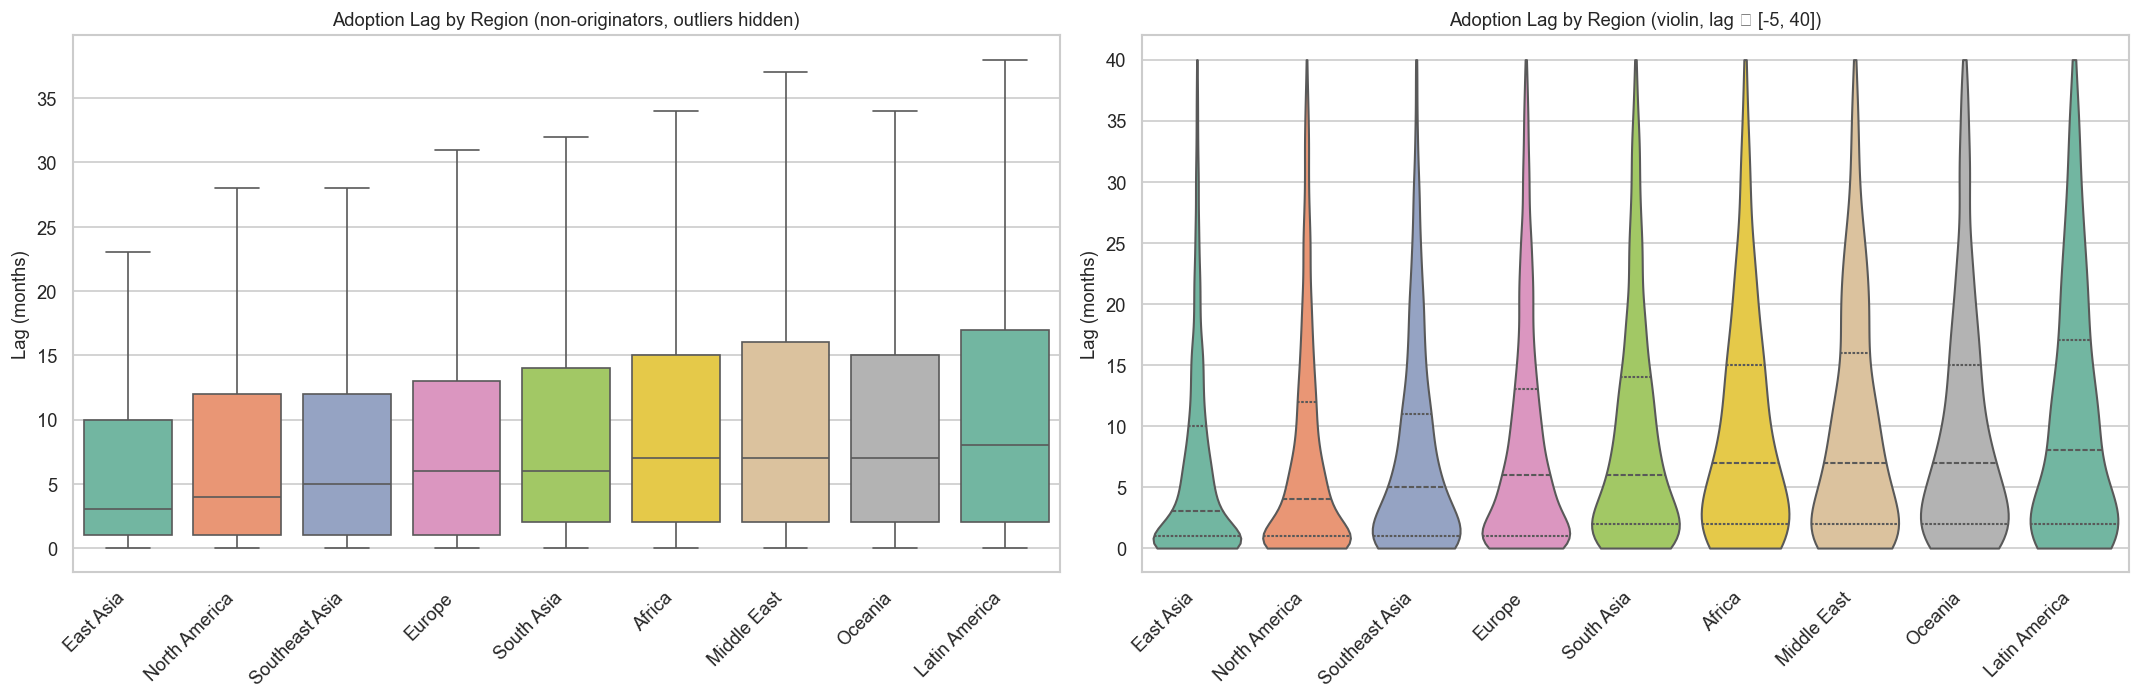


Lag statistics by region (non-originators):


,count,mean,median,std
region,,,,
East Asia,8568,6.60,3.0,8.22
North America,10165,7.87,4.0,9.26
Southeast Asia,1005,7.97,5.0,9.04
Europe,7013,8.98,6.0,9.59
South Asia,1897,9.59,6.0,9.71
Africa,195,9.69,7.0,9.45
Middle East,637,10.04,7.0,9.73
Oceania,776,9.93,7.0,9.79
Latin America,397,10.87,8.0,10.53


In [21]:
# B4: Lag distribution by region
adopt_with_region = adoption.merge(city_attr[['city', 'region']], on='city', how='left')
non_orig = adopt_with_region[adopt_with_region['is_originator'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Box plot
order = non_orig.groupby('region')['lag'].median().sort_values().index
sns.boxplot(data=non_orig, x='region', y='lag', ax=axes[0], order=order,
            palette='Set2', showfliers=False)
axes[0].set_title('Adoption Lag by Region (non-originators, outliers hidden)', fontsize=11)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_xlabel('')
axes[0].set_ylabel('Lag (months)')

# Violin plot
sns.violinplot(data=non_orig[non_orig['lag'].between(-5, 40)], x='region', y='lag',
               ax=axes[1], order=order, palette='Set2', inner='quartile', cut=0)
axes[1].set_title('Adoption Lag by Region (violin, lag ∈ [-5, 40])', fontsize=11)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_xlabel('')
axes[1].set_ylabel('Lag (months)')

plt.tight_layout()
plt.show()

# Summary table
lag_by_region = non_orig.groupby('region')['lag'].agg(['count', 'mean', 'median', 'std']).round(2)
lag_by_region = lag_by_region.sort_values('median')
print('\nLag statistics by region (non-originators):')
display(lag_by_region)

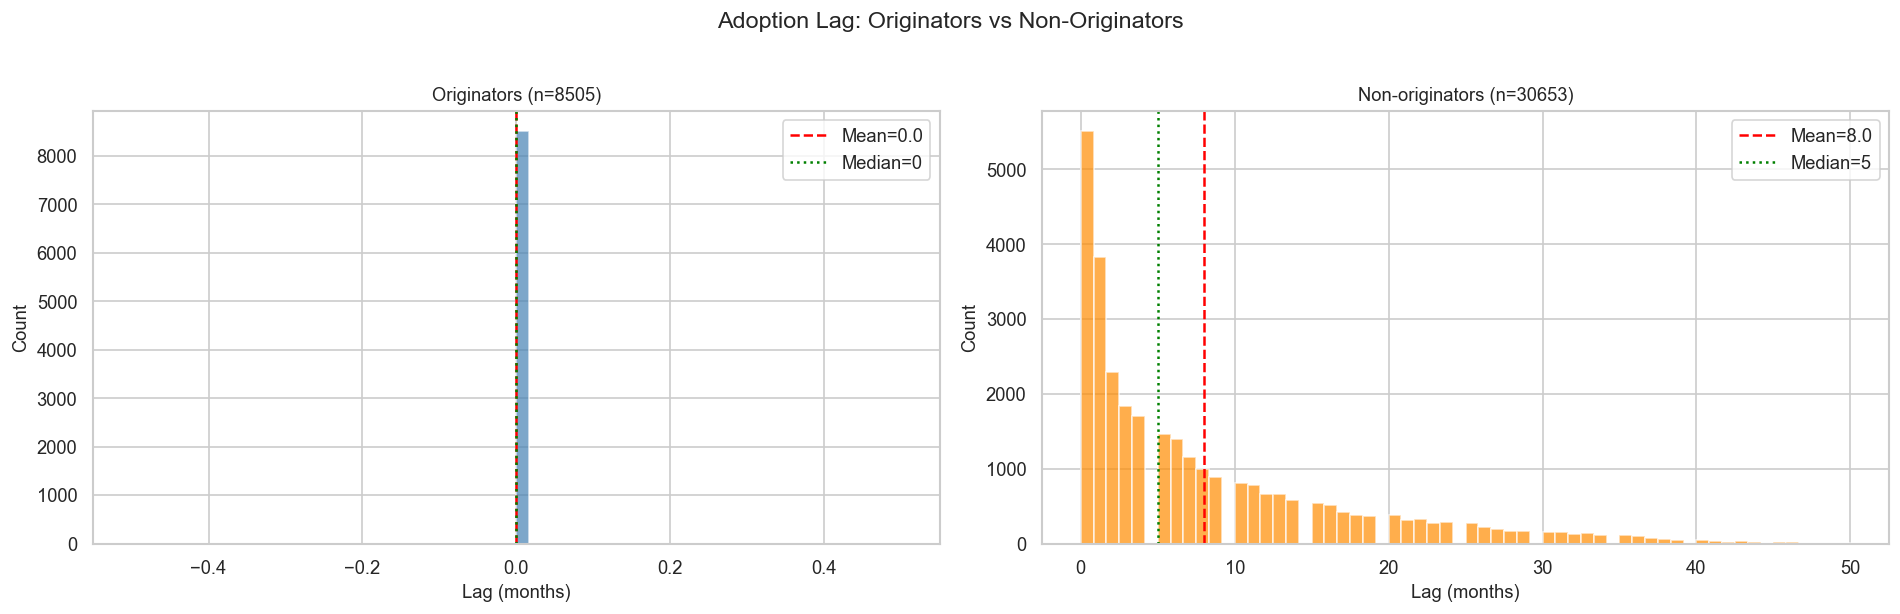

In [22]:
# B5: Lag distribution – originator vs non-originator
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (is_orig, label, color) in zip(axes, [(1, 'Originators', 'steelblue'),
                                                (0, 'Non-originators', 'darkorange')]):
    subset = adoption[adoption['is_originator'] == is_orig]['lag']
    ax.hist(subset, bins=60, edgecolor='white', alpha=0.7, color=color)
    ax.axvline(subset.mean(), color='red', linestyle='--', label=f'Mean={subset.mean():.1f}')
    ax.axvline(subset.median(), color='green', linestyle=':', label=f'Median={subset.median():.0f}')
    ax.set_title(f'{label} (n={len(subset)})', fontsize=11)
    ax.set_xlabel('Lag (months)')
    ax.set_ylabel('Count')
    ax.legend()

fig.suptitle('Adoption Lag: Originators vs Non-Originators', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

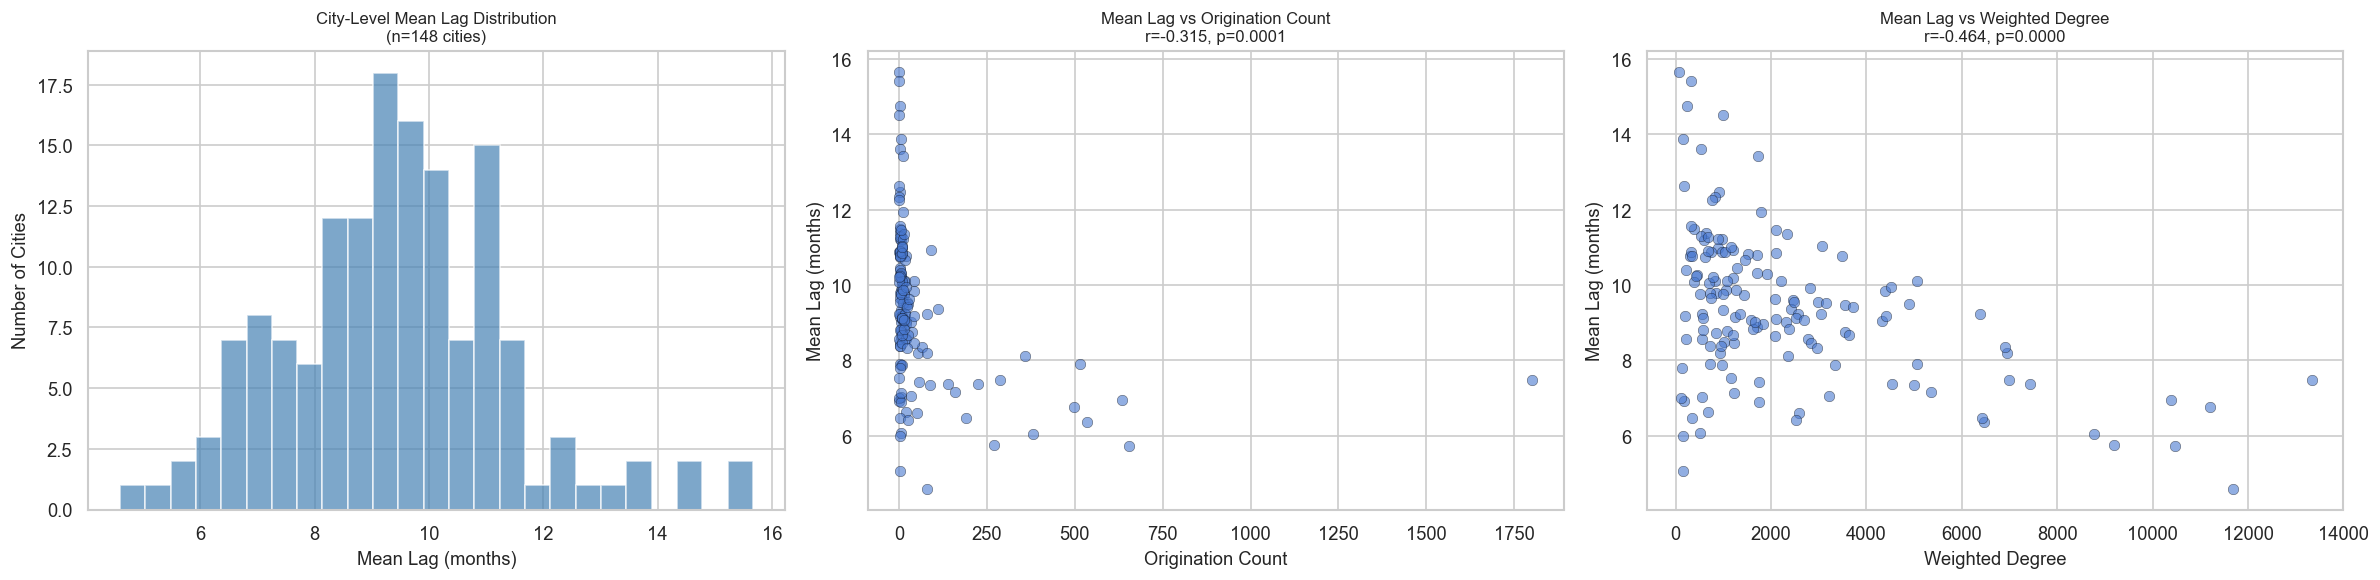

In [23]:
# B6: City-level average lag analysis
city_lag = adoption[adoption['is_originator'] == 0].groupby('city').agg(
    n_adoptions=('lag', 'count'),
    mean_lag=('lag', 'mean'),
    median_lag=('lag', 'median'),
    std_lag=('lag', 'std'),
    n_negative=('lag', lambda x: (x < 0).sum())
).reset_index()

city_lag = city_lag.merge(city_attr[['city', 'region', 'origination_count', 'weighted_degree']],
                          on='city', how='left')

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Mean lag distribution across cities
axes[0].hist(city_lag['mean_lag'].dropna(), bins=25, edgecolor='white',
             alpha=0.7, color='steelblue')
axes[0].set_title(f'City-Level Mean Lag Distribution\n(n={len(city_lag)} cities)', fontsize=10)
axes[0].set_xlabel('Mean Lag (months)')
axes[0].set_ylabel('Number of Cities')

# Mean lag vs origination count
axes[1].scatter(city_lag['origination_count'], city_lag['mean_lag'], alpha=0.6,
                edgecolor='black', linewidth=0.3, s=40)
r, p = stats.pearsonr(city_lag['origination_count'].fillna(0), city_lag['mean_lag'].fillna(0))
axes[1].set_title(f'Mean Lag vs Origination Count\nr={r:.3f}, p={p:.4f}', fontsize=10)
axes[1].set_xlabel('Origination Count')
axes[1].set_ylabel('Mean Lag (months)')

# Mean lag vs weighted degree
axes[2].scatter(city_lag['weighted_degree'], city_lag['mean_lag'], alpha=0.6,
                edgecolor='black', linewidth=0.3, s=40)
r2, p2 = stats.pearsonr(city_lag['weighted_degree'].fillna(0), city_lag['mean_lag'].fillna(0))
axes[2].set_title(f'Mean Lag vs Weighted Degree\nr={r2:.3f}, p={p2:.4f}', fontsize=10)
axes[2].set_xlabel('Weighted Degree')
axes[2].set_ylabel('Mean Lag (months)')

plt.tight_layout()
plt.show()

---
## Part C – Feature Relationships: Deeper Analysis

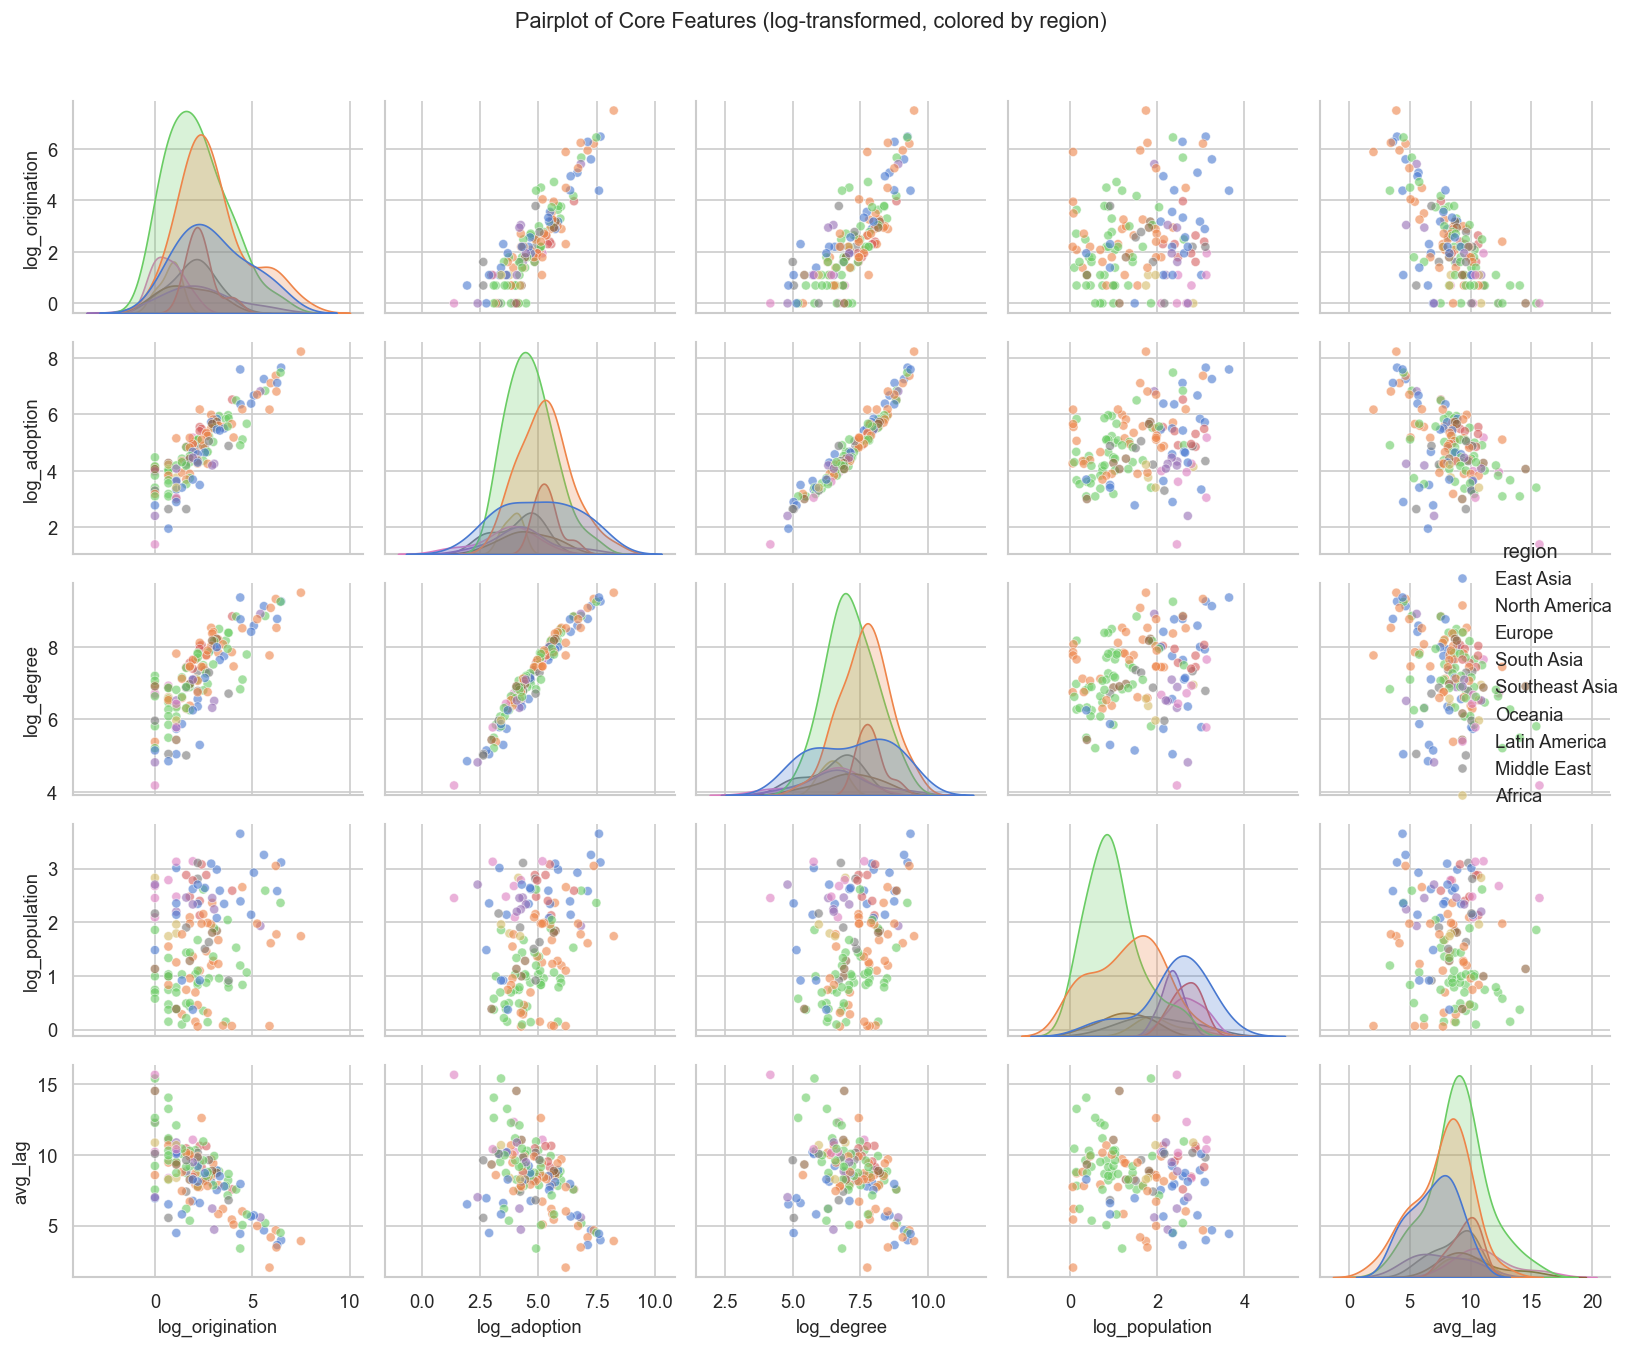

In [24]:
# C1: Pairplot for core features (log-transformed where appropriate)
pair_df = city_attr[city_attr['adoption_count'] > 0].copy()
pair_df['log_origination'] = np.log1p(pair_df['origination_count'])
pair_df['log_adoption'] = np.log1p(pair_df['adoption_count'])
pair_df['log_degree'] = np.log1p(pair_df['weighted_degree'])
pair_df['log_population'] = np.log1p(pair_df['population_million'])

pair_cols = ['log_origination', 'log_adoption', 'log_degree',
             'log_population', 'avg_lag']

g = sns.pairplot(pair_df, vars=pair_cols, hue='region', diag_kind='kde',
                 plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'white'},
                 height=2.2, aspect=1.1)
g.figure.suptitle('Pairplot of Core Features (log-transformed, colored by region)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [25]:
# C2: Variance Inflation Factor (VIF) for multicollinearity detection
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_cols = ['origination_count', 'adoption_count', 'collaboration_count',
            'weighted_degree', 'betweenness', 'eigenvector_centrality',
            'population_million', 'gdp_per_capita', 'entity_count',
            'education_tertiary_pct', 'internet_users_pct', 'rd_expenditure_pct',
            'research_capacity']

vif_data = city_attr[vif_cols].dropna()

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
vif_scaled = pd.DataFrame(scaler.fit_transform(vif_data), columns=vif_cols)

vif_results = pd.DataFrame({
    'Feature': vif_cols,
    'VIF': [variance_inflation_factor(vif_scaled.values, i) for i in range(len(vif_cols))]
}).sort_values('VIF', ascending=False)

print('Variance Inflation Factor (VIF):')
print('VIF > 10 suggests severe multicollinearity; VIF > 5 is concerning.')
print()
display(vif_results.round(2))

Variance Inflation Factor (VIF):
VIF > 10 suggests severe multicollinearity; VIF > 5 is concerning.



,Feature,VIF
2,collaboration_count,inf
3,weighted_degree,inf
5,eigenvector_centrality,524.43
1,adoption_count,44.07
0,origination_count,13.76
8,entity_count,10.11
7,gdp_per_capita,3.55
10,internet_users_pct,2.83
6,population_million,2.83
12,research_capacity,2.37


In [26]:
# C3: Partial correlation – controlling for population / entity_count
def partial_corr(df, x, y, controls):
    """Compute partial correlation between x and y, controlling for controls."""
    from sklearn.linear_model import LinearRegression
    data = df[[x, y] + controls].dropna()
    if len(data) < 10:
        return float('nan'), float('nan')
    X_ctrl = data[controls].values

    reg_x = LinearRegression().fit(X_ctrl, data[x])
    resid_x = data[x] - reg_x.predict(X_ctrl)

    reg_y = LinearRegression().fit(X_ctrl, data[y])
    resid_y = data[y] - reg_y.predict(X_ctrl)

    r, p = stats.pearsonr(resid_x, resid_y)
    return r, p

print('=' * 80)
print('PARTIAL CORRELATIONS (controlling for population_million & entity_count)')
print('=' * 80)

controls = ['population_million', 'entity_count']
target_pairs = [
    ('origination_count', 'adoption_count'),
    ('origination_count', 'weighted_degree'),
    ('adoption_count', 'weighted_degree'),
    ('gdp_per_capita', 'origination_count'),
    ('gdp_per_capita', 'adoption_count'),
    ('education_tertiary_pct', 'origination_count'),
    ('research_capacity', 'origination_count'),
    ('rd_expenditure_pct', 'origination_count'),
    ('internet_users_pct', 'adoption_count'),
]

print(f'{"Variable X":<30} {"Variable Y":<25} {"Raw r":>8} {"Partial r":>10} {"Partial p":>12}')
print('-' * 80)

for x, y in target_pairs:
    valid = city_attr[[x, y]].dropna()
    if len(valid) >= 3:
        raw_r, _ = stats.pearsonr(valid[x], valid[y])
    else:
        raw_r = float('nan')
    pr, pp = partial_corr(city_attr, x, y, controls)
    print(f'{x:<30} {y:<25} {raw_r:>8.3f} {pr:>10.3f} {pp:>12.6f}')

PARTIAL CORRELATIONS (controlling for population_million & entity_count)
Variable X                     Variable Y                   Raw r  Partial r    Partial p
--------------------------------------------------------------------------------
origination_count              adoption_count               0.899      0.672     0.000000
origination_count              weighted_degree              0.709     -0.108     0.198215
adoption_count                 weighted_degree              0.918      0.498     0.000000
gdp_per_capita                 origination_count            0.103      0.008     0.928879
gdp_per_capita                 adoption_count               0.056      0.266     0.002221
education_tertiary_pct         origination_count            0.059     -0.011     0.898230
research_capacity              origination_count            0.454     -0.070     0.406530
rd_expenditure_pct             origination_count            0.124     -0.005     0.951204
internet_users_pct             adopt

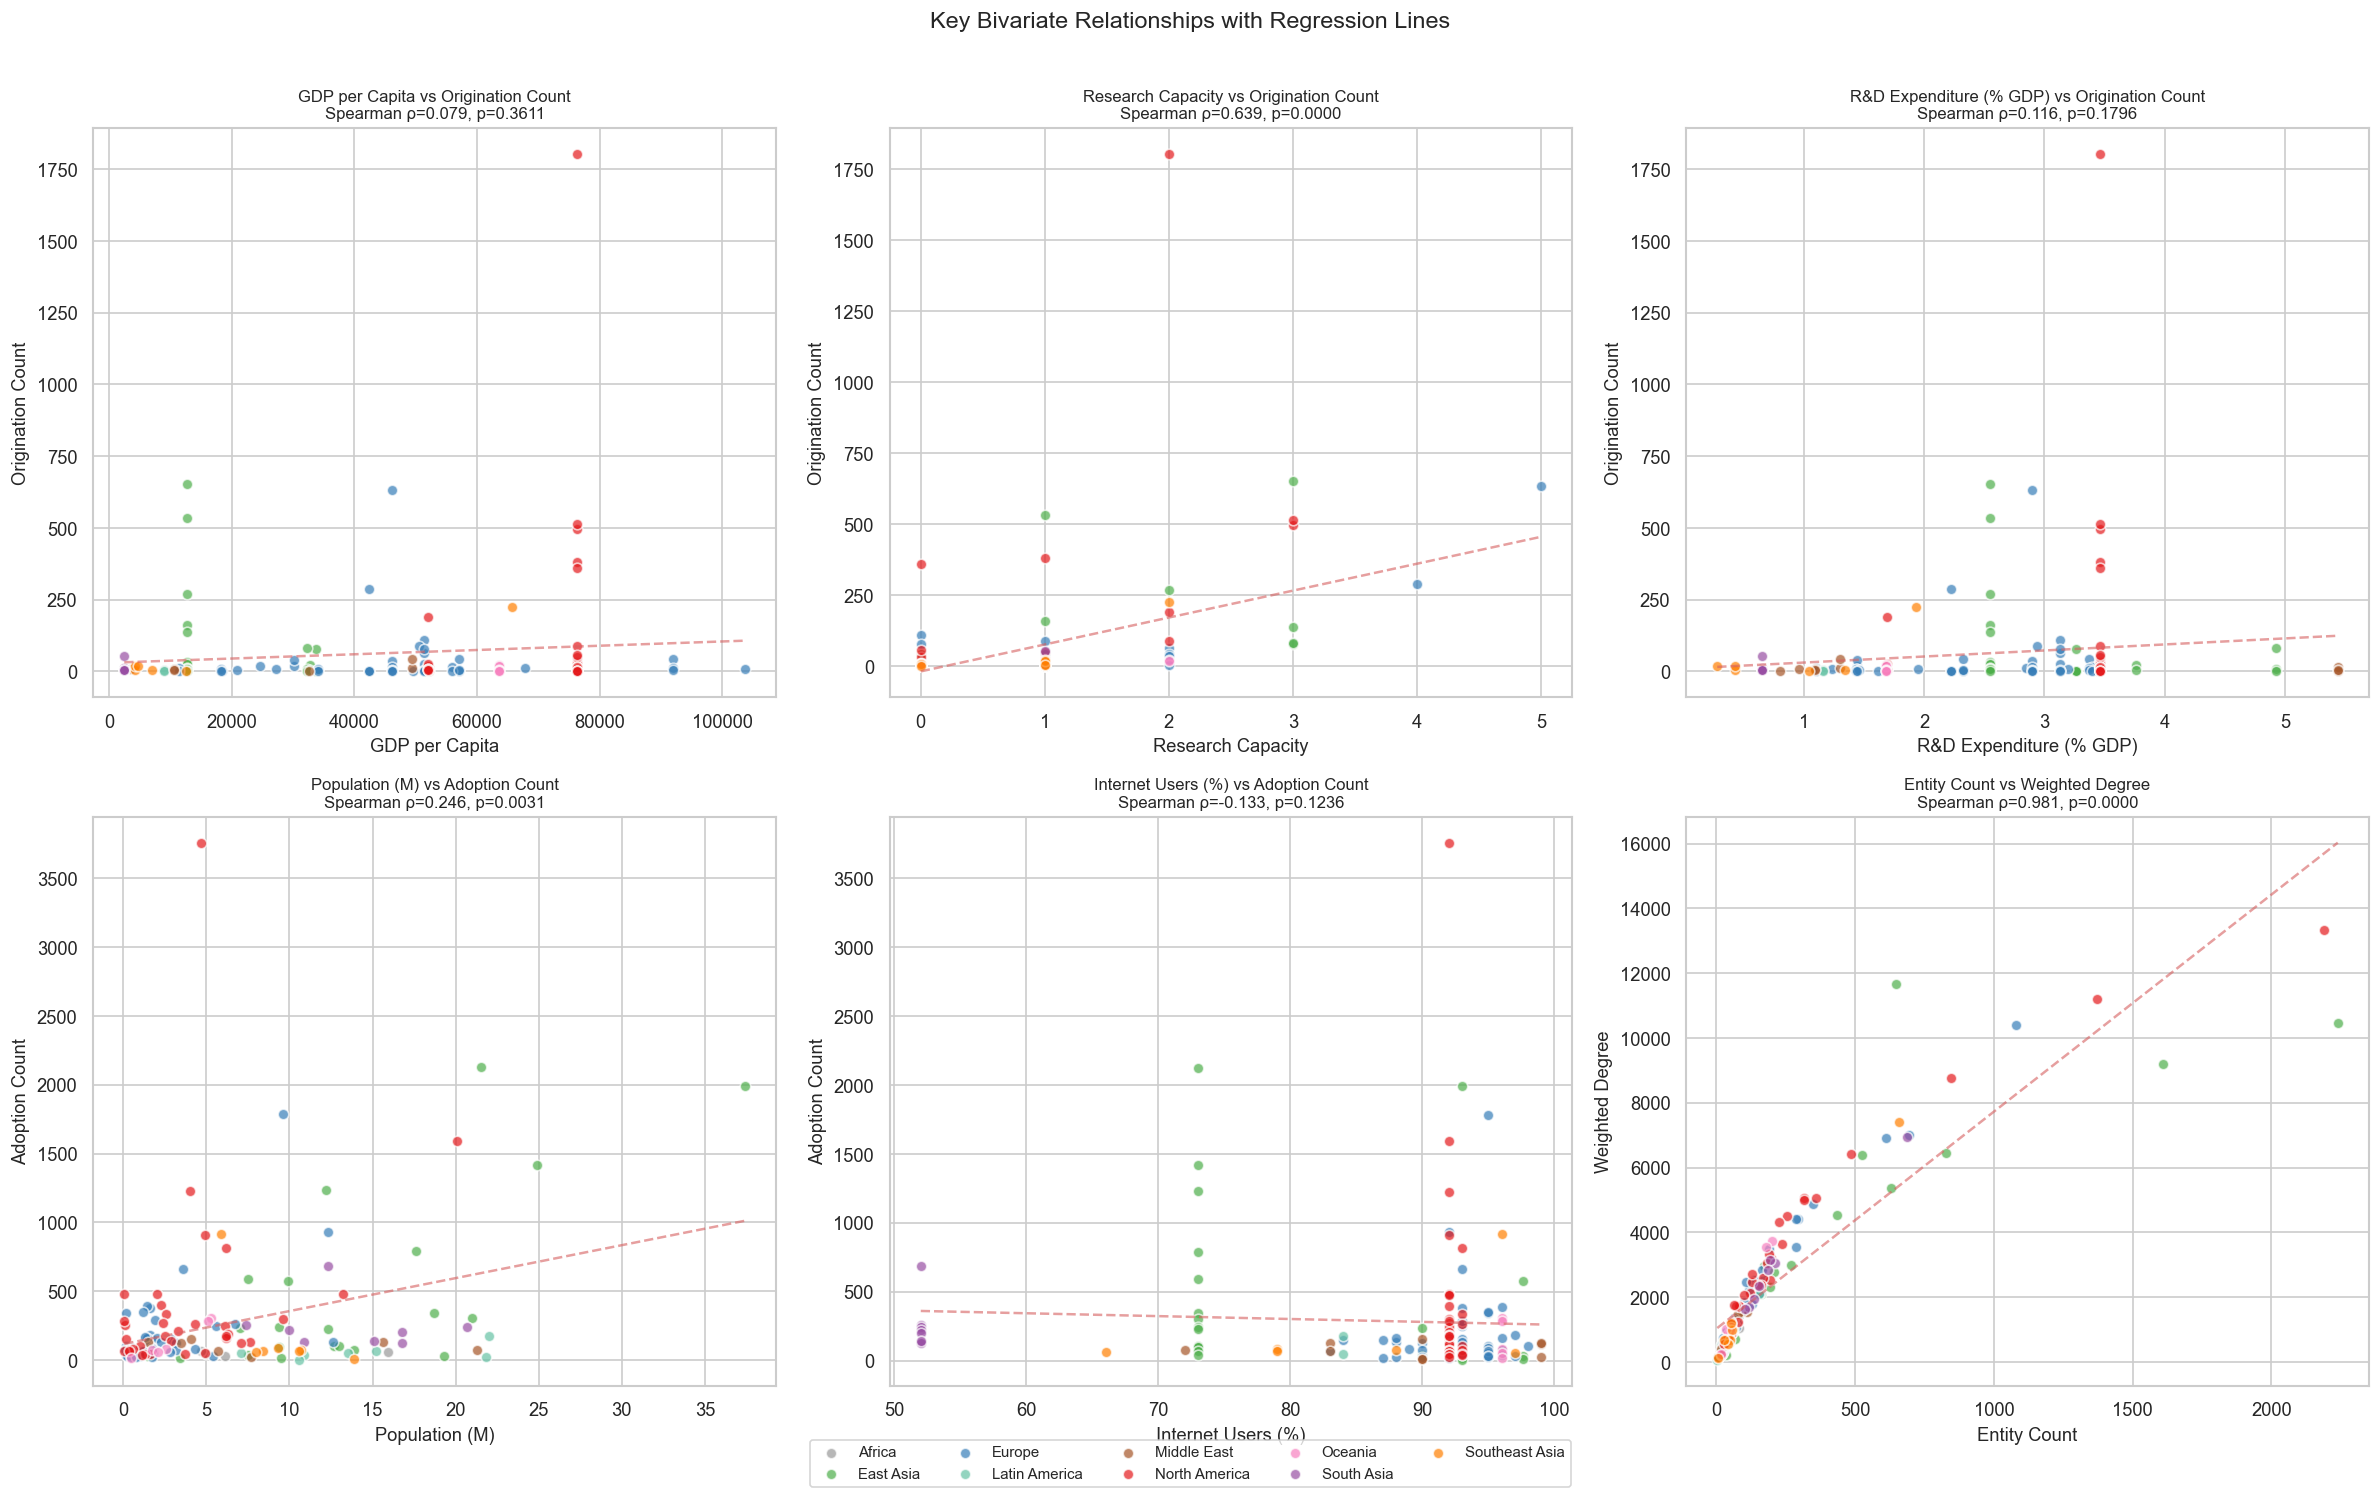

In [27]:
# C4: Detailed scatter with regression lines for key relationships
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

scatter_configs = [
    ('gdp_per_capita', 'origination_count', 'GDP per Capita', 'Origination Count'),
    ('research_capacity', 'origination_count', 'Research Capacity', 'Origination Count'),
    ('rd_expenditure_pct', 'origination_count', 'R&D Expenditure (% GDP)', 'Origination Count'),
    ('population_million', 'adoption_count', 'Population (M)', 'Adoption Count'),
    ('internet_users_pct', 'adoption_count', 'Internet Users (%)', 'Adoption Count'),
    ('entity_count', 'weighted_degree', 'Entity Count', 'Weighted Degree'),
]

region_colors = {
    'North America': '#e41a1c', 'Europe': '#377eb8', 'East Asia': '#4daf4a',
    'South Asia': '#984ea3', 'Southeast Asia': '#ff7f00', 'Middle East': '#a65628',
    'Oceania': '#f781bf', 'Africa': '#999999', 'Latin America': '#66c2a5',
}

for ax, (xc, yc, xlabel, ylabel) in zip(axes.flatten(), scatter_configs):
    for region, grp in city_attr.groupby('region'):
        ax.scatter(grp[xc], grp[yc], c=region_colors.get(region, 'grey'),
                   label=region, alpha=0.7, edgecolor='white', s=40)

    valid = city_attr[[xc, yc]].dropna()
    if len(valid) >= 3:
        r_s, p_s = stats.spearmanr(valid[xc], valid[yc])
        z = np.polyfit(valid[xc], valid[yc], 1)
        p_fit = np.poly1d(z)
        x_range = np.linspace(valid[xc].min(), valid[xc].max(), 100)
        ax.plot(x_range, p_fit(x_range), 'r--', alpha=0.6, linewidth=1.5)
        ax.set_title(f'{xlabel} vs {ylabel}\nSpearman ρ={r_s:.3f}, p={p_s:.4f}', fontsize=10)
    else:
        ax.set_title(f'{xlabel} vs {ylabel}', fontsize=10)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Key Bivariate Relationships with Regression Lines', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Correlations with avg_lag (cities with adoption_count > 0):
(Negative correlation = feature associated with faster adoption)


,Feature,Pearson r,Pearson p,Spearman ρ,Spearman p
0,origination_count,-0.4718,0.0000,-0.6112,0.0000
1,adoption_count,-0.5111,0.0000,-0.4402,0.0000
8,entity_count,-0.4702,0.0000,-0.3863,0.0000
5,eigenvector_centrality,-0.5102,0.0000,-0.3836,0.0000
2,collaboration_count,-0.4985,0.0000,-0.3720,0.0000
3,weighted_degree,-0.4985,0.0000,-0.3720,0.0000
11,rd_expenditure_pct,-0.2896,0.0007,-0.3362,0.0001
12,research_capacity,-0.3648,0.0000,-0.2737,0.0008
7,gdp_per_capita,-0.1602,0.0635,-0.1864,0.0304
9,education_tertiary_pct,-0.0480,0.5807,-0.1093,0.2069


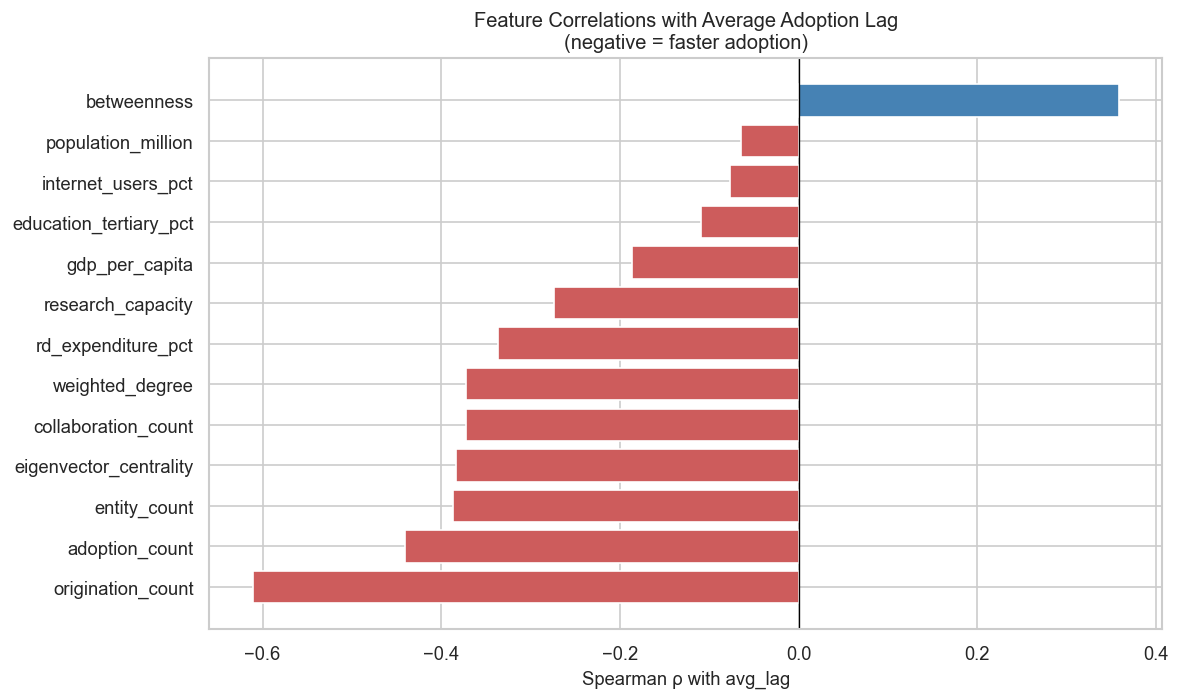

In [28]:
# C5: Correlation with avg_lag – what predicts faster adoption?
lag_cities = city_attr[city_attr['adoption_count'] > 0].copy()

corr_with_lag = []
test_cols = ['origination_count', 'adoption_count', 'collaboration_count',
             'weighted_degree', 'betweenness', 'eigenvector_centrality',
             'population_million', 'gdp_per_capita', 'entity_count',
             'education_tertiary_pct', 'internet_users_pct', 'rd_expenditure_pct',
             'research_capacity']

for col in test_cols:
    valid = lag_cities[['avg_lag', col]].dropna()
    if len(valid) >= 3:
        r_p, p_p = stats.pearsonr(valid['avg_lag'], valid[col])
        r_s, p_s = stats.spearmanr(valid['avg_lag'], valid[col])
        corr_with_lag.append({'Feature': col, 'Pearson r': r_p, 'Pearson p': p_p,
                              'Spearman ρ': r_s, 'Spearman p': p_s})

corr_lag_df = pd.DataFrame(corr_with_lag).sort_values('Spearman ρ')

print('Correlations with avg_lag (cities with adoption_count > 0):')
print('(Negative correlation = feature associated with faster adoption)')
display(corr_lag_df.round(4))

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['indianred' if x < 0 else 'steelblue' for x in corr_lag_df['Spearman ρ']]
ax.barh(corr_lag_df['Feature'], corr_lag_df['Spearman ρ'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Spearman ρ with avg_lag')
ax.set_title('Feature Correlations with Average Adoption Lag\n(negative = faster adoption)', fontsize=12)
plt.tight_layout()
plt.show()

In [29]:
# C6: Grouped comparison – top vs bottom cities
active_cities = city_attr[city_attr['adoption_count'] > 0].copy()
n_group = max(10, len(active_cities) // 4)

top_cities = active_cities.nlargest(n_group, 'origination_count')
bottom_cities = active_cities.nsmallest(n_group, 'origination_count')

compare_cols = ['adoption_count', 'avg_lag', 'weighted_degree',
                'population_million', 'gdp_per_capita', 'research_capacity',
                'rd_expenditure_pct', 'internet_users_pct']

print(f'Top {n_group} vs Bottom {n_group} cities by origination_count:')
print('=' * 90)
print(f'{"Feature":<25} {"Top Mean":>12} {"Bottom Mean":>12} {"Ratio":>8} {"Mann-Whitney p":>16}')
print('-' * 90)

for col in compare_cols:
    top_vals = top_cities[col].dropna()
    bot_vals = bottom_cities[col].dropna()
    if len(top_vals) < 2 or len(bot_vals) < 2:
        continue
    top_mean = top_vals.mean()
    bot_mean = bot_vals.mean()
    ratio = top_mean / bot_mean if bot_mean != 0 else float('inf')
    _, p_val = stats.mannwhitneyu(top_vals, bot_vals, alternative='two-sided')
    sig = ' ***' if p_val < 0.001 else (' **' if p_val < 0.01 else (' *' if p_val < 0.05 else ''))
    print(f'{col:<25} {top_mean:>12.2f} {bot_mean:>12.2f} {ratio:>8.2f} {p_val:>14.6f}{sig}')

Top 37 vs Bottom 37 cities by origination_count:
Feature                       Top Mean  Bottom Mean    Ratio   Mann-Whitney p
------------------------------------------------------------------------------------------
adoption_count                  751.30        44.49    16.89       0.000000 ***
avg_lag                           5.98        10.25     0.58       0.000000 ***
weighted_degree                5273.92       637.84     8.27       0.000000 ***
population_million                8.29         5.15     1.61       0.120822
gdp_per_capita                48273.51     43693.12     1.10       0.328175
research_capacity                 1.62         0.19     8.57       0.000000 ***
rd_expenditure_pct                2.78         2.69     1.03       0.517513
internet_users_pct               88.04        91.98     0.96       0.531011


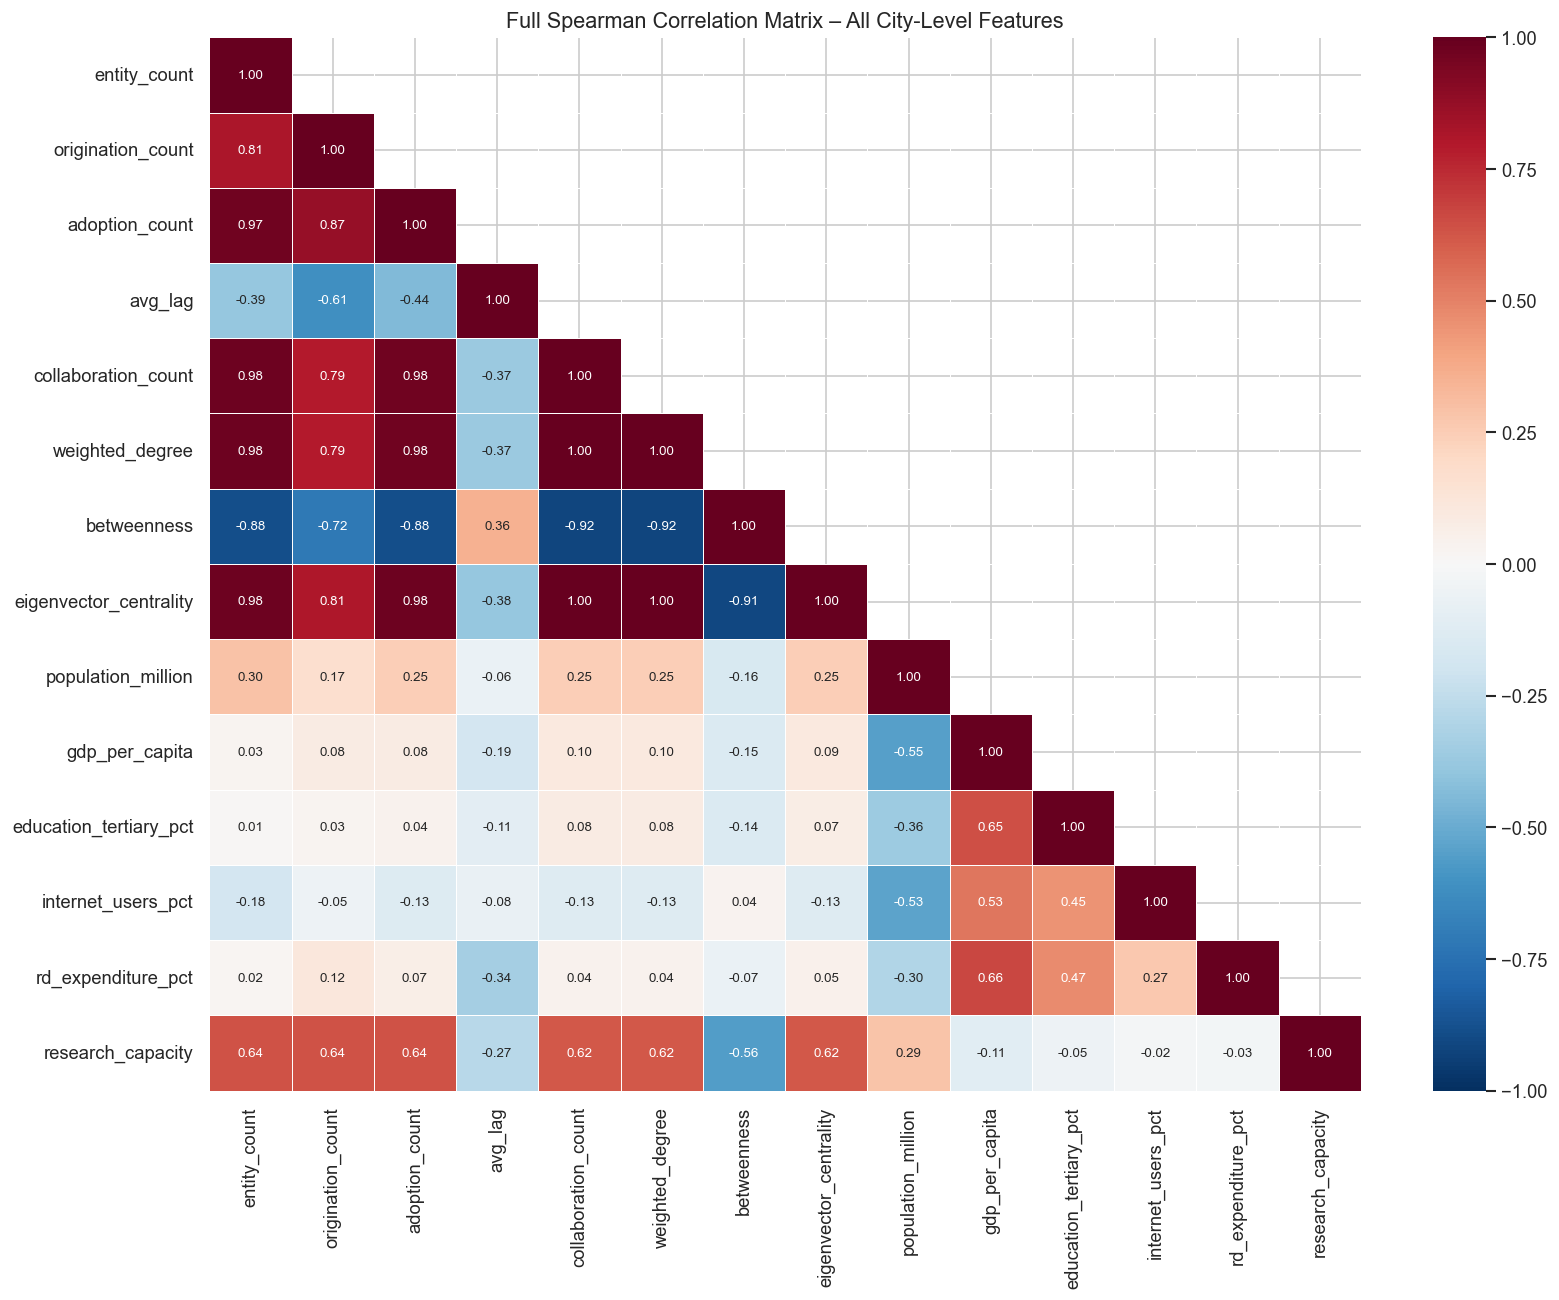

In [30]:
# C7: Full Spearman correlation heatmap with all relevant features
all_corr_cols = [
    'entity_count', 'origination_count', 'adoption_count',
    'avg_lag', 'collaboration_count', 'weighted_degree',
    'betweenness', 'eigenvector_centrality',
    'population_million', 'gdp_per_capita',
    'education_tertiary_pct', 'internet_users_pct', 'rd_expenditure_pct',
    'research_capacity'
]

corr_matrix = city_attr[all_corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, center=0, ax=ax, linewidths=0.5,
            annot_kws={'size': 8})
ax.set_title('Full Spearman Correlation Matrix – All City-Level Features', fontsize=13)
plt.tight_layout()
plt.show()